<a href="https://colab.research.google.com/github/shinbrooke/shinbrooke.github.io/blob/main/human_v_machinecoding.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# Settings
import pandas as pd
import numpy as np

#시각화용
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

In [4]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
plist1 = ['p01', 'p02', 'p03', 'p04', 'p05', 'p06', 'p07', 'p08', 'p09', 'p10',
          'p11', 'p12', 'p13', 'p14', 'p15', 'p16', 'p17', 'p18', 'p19', 'p20',
          'p21', 'p22', 'p23', 'p24', 'p25', 'p27', 'p28', 'p29', 'p30',
          'p31', 'p32']

# combine chats for prompt analysis

In [ ]:
logs = pd.read_csv('/content/drive/My Drive/2023_인간-AI 협력 역량 진단/8. analysis/combined_logs2.csv')
logs.columns

<ipython-input-4-194b9d134122>:1: DtypeWarning: Columns (18) have mixed types. Specify dtype option on import or set low_memory=False.
  logs = pd.read_csv('/content/drive/My Drive/2023_인간-AI 협력 역량 진단/8. analysis/combined_logs2.csv')


Index(['Unnamed: 0', 'object', 'timestamp', 'eventtype', 'eventdata',
       'taskcomplexity', 'tasktopic', 'participant', 'edit', '내용_정보검색',
       '내용_메타인지', '내용_과제수행', '내용_협상', '내용_기타', '유형_신규', '유형_반복', '유형_추가',
       '정교성', '사회정서적 표현', 'fromstart', 'sentences', '글쓰기', '수정', 'changes',
       '계획', '점검_인간', '점검_AI', '프롬프트', '복사', '붙여넣기', 'AI답변', 'fromstart_s',
       'duration_s', '내용_메타인지_계획', '내용_메타인지_평가'],
      dtype='object')

In [ ]:
logs2 = logs.drop(['내용_정보검색', 'Unnamed: 0',
       '내용_메타인지', '내용_과제수행', '내용_협상', '내용_기타', '유형_신규', '유형_반복', '유형_추가',
       '정교성', '사회정서적 표현', 'fromstart', 'sentences', '글쓰기', '수정', 'changes',
       '계획', '점검_인간', '점검_AI', '프롬프트', '복사', '붙여넣기', 'AI답변', 'fromstart_s',
       'duration_s', '내용_메타인지_계획', '내용_메타인지_평가'], axis=1)
logs2.head()

,object,timestamp,eventtype,eventdata,taskcomplexity,tasktopic,participant,edit
0,start,1.711352e+12,participant,p01,simple,fossilfuel,p01,0
1,prob,1.711352e+12,mouseover,view,simple,fossilfuel,p01,0
2,doc,1.711352e+12,mouseover,view,simple,fossilfuel,p01,0
3,doc,1.711352e+12,mouseout,move,simple,fossilfuel,p01,0
4,plan,1.711352e+12,mouseover,view,simple,fossilfuel,p01,0


In [ ]:
logs3 = logs2[(logs2['eventtype'] == 'user') | (logs2['eventtype'] == 'assistant')]
logs3.head()

,object,timestamp,eventtype,eventdata,taskcomplexity,tasktopic,participant,edit
29,Limit Fossil Fuel Use,1.711352e+12,user,['전 세계적으로 화석 연료의 사용을 제한해야 한다는 입장에 대해 찬성하는 글을 쓰...,simple,fossilfuel,p01,False
33,Limit Fossil Fuel Use,1.711352e+12,assistant,['화석 연료의 사용을 제한하는 것은 지구 환경을 보호하고 지구 온난화의 영향을 최...,simple,fossilfuel,p01,False
37,Limit Fossil Fuel Use,1.711352e+12,user,['다른 근거들도 알려줘'],simple,fossilfuel,p01,False
54,Limit Fossil Fuel Use,1.711352e+12,assistant,['물론입니다. 화석 연료 사용을 제한하는 것에 대한 더 많은 근거를 알려드리겠습니...,simple,fossilfuel,p01,False
579,Limit Fossil Fuel Use,1.711353e+12,user,['다 비슷한 말이네. 일단 고마워'],simple,fossilfuel,p01,False


In [ ]:
logs3.to_excel('/content/drive/My Drive/2023_인간-AI 협력 역량 진단/8. analysis/combined_chats.xlsx')

# Data loading for 상호작용 행동 빈도분석

In [22]:
# 비디오 코딩 데이터 불러오기
# xls = pd.read_ExcelFile("/content/drive/MyDrive/2023_인간-AI 협력 역량 진단/8. analysis/Atlas.ti/[ENA용]/HAIcollab_0726.xlsx")
xls = pd.read_excel("/content/drive/MyDrive/2023_인간-AI 협력 역량 진단/8. analysis/Atlas.ti/[ENA용]/HAIcollab_0726.xlsx", sheet_name="Rawdata")

# 로그데이터 불러오기
logs = pd.read_csv('/content/drive/My Drive/2023_인간-AI 협력 역량 진단/8. analysis/combined_logs2.csv')

<ipython-input-22-0711a24ade9f>:6: DtypeWarning: Columns (18) have mixed types. Specify dtype option on import or set low_memory=False.
  logs = pd.read_csv('/content/drive/My Drive/2023_인간-AI 협력 역량 진단/8. analysis/combined_logs2.csv')


In [23]:
xls = xls.drop(['start_time', 'end_time'], axis=1)

In [24]:
logs.columns = ['Unnamed: 0', 'object', 'timestamp', 'eventtype', 'eventdata',
       'taskcomplexity', 'tasktopic', 'participant', 'edit', '내용_정보검색',
       '내용_메타인지', '내용_과제수행', '내용_협상', '내용_기타', '유형_신규', '유형_반복', '유형_추가',
       '정교성', '사회정서적 표현', 'fromstart', 'sentences', 'writing', 'writing_revise', 'changes',
       'planning', 'Human_monitoring', 'AI_monitoring', 'prompting', 'copy', 'paste', 'AI_response', 'fromstart_s',
       'duration_s','내용_메타인지_계획', '내용_메타인지_평가']
logs = logs.drop(['Unnamed: 0', 'object', 'timestamp', 'eventtype', 'eventdata', 'edit', '내용_정보검색',
       '내용_메타인지', '내용_과제수행', '내용_협상', '내용_기타', '유형_신규', '유형_반복', '유형_추가',
       '정교성', '사회정서적 표현', 'fromstart', 'sentences', 'changes', 'paste','fromstart_s', 'duration_s', '내용_메타인지_계획', '내용_메타인지_평가'], axis=1)

In [25]:
xls = xls.drop('tasktopic', axis=1)
logs = logs.drop('tasktopic', axis=1)
xls_simple = xls[xls.taskcomplexity == 'simple']
xls_complex = xls[xls.taskcomplexity == 'complex']
logs_simple = logs[logs.taskcomplexity == 'simple']
logs_complex = logs[logs.taskcomplexity == 'complex']

In [26]:
human_freq_simple = xls_simple.groupby(['participant']).sum().drop('taskcomplexity', axis=1)
human_freq_complex = xls_complex.groupby(['participant']).sum().drop('taskcomplexity', axis=1)
logs_freq_simple = logs_simple.groupby(['participant']).sum().drop('taskcomplexity', axis=1)
logs_freq_complex = logs_complex.groupby(['participant']).sum().drop('taskcomplexity', axis=1)

In [27]:
# First, let's create a function that can handle this for any two similar datasets
def average_datasets(df1, df2):
    # Ensure both dataframes have the same shape
    if df1.shape != df2.shape:
        raise ValueError("Datasets must have the same dimensions")

    # Calculate the average
    averaged_df = (df1 + df2) / 2

    # Round to integers if needed
    # averaged_df = averaged_df.round().astype(int)  # Uncomment if you want integers

    return averaged_df

# Example usage with your data:

# Convert string data to DataFrames
from io import StringIO
df1 = human_freq_simple
df2 = human_freq_complex

# Set the participant column as index
#df1 = df1.set_index('participant')
#df2 = df2.set_index('participant')

# Calculate average
result = average_datasets(df1, df2)

# If you want to save the result
df_human = result
result.to_csv('/content/drive/MyDrive/2023_인간-AI 협력 역량 진단/8. analysis/human_averaged.csv')

# Display the result
result.head()

,AI_monitoring,AI_response,blank,copy,Human_monitoring,planning,prompting,writing,writing_revise
participant,,,,,,,,,
p01,0.0,2.5,2.0,0.0,0.5,1.0,2.5,4.0,0.0
p02,2.5,6.0,15.0,1.5,9.5,2.0,6.0,5.5,19.0
p03,2.0,11.0,21.5,0.5,3.5,7.5,12.0,13.0,6.0
p04,7.5,5.0,35.5,0.0,3.0,2.0,6.0,22.0,1.5
p05,11.5,38.5,29.0,18.5,3.5,3.5,39.5,5.5,28.5


In [28]:
# for logs
df1 = logs_freq_simple
df2 = logs_freq_complex

# Calculate average
result = average_datasets(df1, df2)

# If you want to save the result
df_logs = result
result.to_csv('/content/drive/MyDrive/2023_인간-AI 협력 역량 진단/8. analysis/logs_averaged.csv')

# Display the result
result.head()

,writing,writing_revise,planning,Human_monitoring,AI_monitoring,prompting,copy,AI_response
participant,,,,,,,,
p01,378.0,26.5,22.0,0.0,2.5,2.5,0.0,2.5
p02,122.0,288.0,74.5,2.5,15.5,6.0,0.0,6.0
p03,386.0,61.5,160.5,13.5,21.0,11.0,1.5,11.0
p04,173.0,5.0,24.5,6.0,10.5,5.0,0.0,6.0
p05,0.0,253.5,75.0,41.0,45.5,37.5,11.5,40.0


# 상호작용 행동 상관분석

In [29]:
from scipy import stats
import seaborn as sns
import matplotlib.pyplot as plt

## averaged

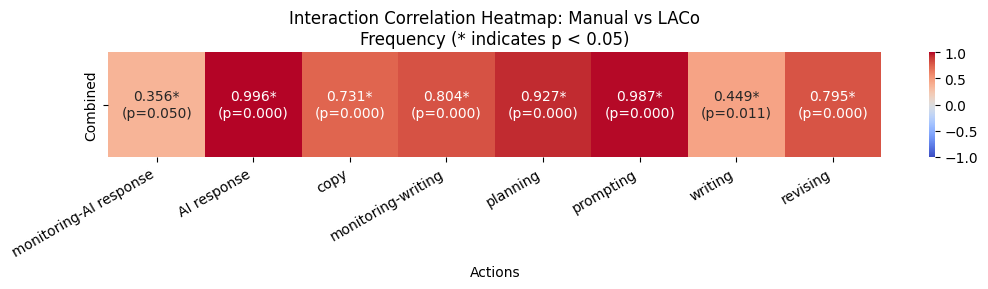

In [31]:
def calculate_correlations_with_significance(df1, df2):
    common_columns = df1.columns.intersection(df2.columns)
    correlations = {}
    p_values = {}

    for col in common_columns:
        corr, p_value = stats.pearsonr(df1[col], df2[col])
        correlations[col] = corr
        p_values[col] = p_value

    return pd.Series(correlations), pd.Series(p_values)

# Calculate correlations and p-values for both conditions
corr_combined, p_combined = calculate_correlations_with_significance(df_human, df_logs)

# Combine correlations
combined_correlations = pd.DataFrame({
    'Combined': corr_combined
}).T

# Define the desired column order
column_order = ["AI_monitoring", "AI_response", "copy", "Human_monitoring", "planning", "prompting", "writing", "writing_revise"]

# Define the new column names
new_column_names = ["monitoring-AI response", "AI response", "copy", "monitoring-writing", "planning", "prompting", "writing", "revising"]

# Reorder columns in the correlations DataFrame
combined_correlations = combined_correlations[column_order]

# Create annotation matrix with both correlations and p-values
def create_annotations(correlations, p_values):
    return [f'{corr:.3f}*\n(p={p:.3f})' if p < 0.05 else f'{corr:.3f}\n(p={p:.3f})'
            for corr, p in zip(correlations, p_values)]

# Reorder p_values to match the column order
p_combined_ordered = p_combined[column_order]

annotations = np.array([
    create_annotations(combined_correlations.iloc[0], p_combined_ordered)
])

# Create the heatmap
plt.figure(figsize=(11, 3))

# Create heatmap with adjusted cell size for two-line annotations
sns.heatmap(combined_correlations,
            annot=annotations,
            cmap='coolwarm',
            vmin=-1,
            vmax=1,
            center=0,
            fmt='',
            xticklabels=new_column_names,
            yticklabels=combined_correlations.index,
            cbar_kws={'ticks': [-1, -0.5, 0, 0.5, 1]})

# Rotate x-axis labels
plt.xticks(rotation=30, ha='right')

plt.title('Interaction Correlation Heatmap: Manual vs LACo\nFrequency (* indicates p < 0.05)')
plt.xlabel('Actions')

# Adjust layout to prevent label cutoff
plt.tight_layout()
plt.show()

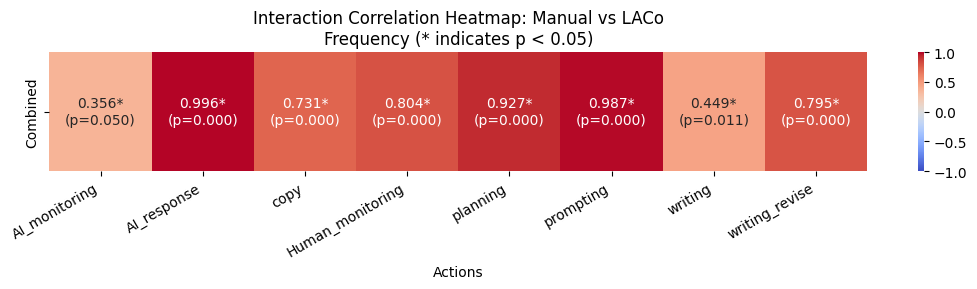

In [30]:
def calculate_correlations_with_significance(df1, df2):
    common_columns = df1.columns.intersection(df2.columns)
    correlations = {}
    p_values = {}

    for col in common_columns:
        corr, p_value = stats.pearsonr(df1[col], df2[col])
        correlations[col] = corr
        p_values[col] = p_value

    return pd.Series(correlations), pd.Series(p_values)

# Calculate correlations and p-values for both conditions
corr_combined, p_combined = calculate_correlations_with_significance(df_human, df_logs)

# Combine correlations
combined_correlations = pd.DataFrame({
    'Combined': corr_combined
}).T

# Create annotation matrix with both correlations and p-values
def create_annotations(correlations, p_values):
    return [f'{corr:.3f}*\n(p={p:.3f})' if p < 0.05 else f'{corr:.3f}\n(p={p:.3f})'
            for corr, p in zip(correlations, p_values)]

annotations = np.array([
    create_annotations(corr_combined, p_combined)
])

# Create the heatmap
plt.figure(figsize=(11, 3))

# Create heatmap with adjusted cell size for two-line annotations
sns.heatmap(combined_correlations,
            annot=annotations,
            cmap='coolwarm',
            vmin=-1,
            vmax=1,
            center=0,
            fmt='',
            xticklabels=combined_correlations.columns,
            yticklabels=combined_correlations.index)

# Rotate x-axis labels
plt.xticks(rotation=30, ha='right')

plt.title('Interaction Correlation Heatmap: Manual vs LACo\nFrequency (* indicates p < 0.05)')
#plt.ylabel('Task Type')
plt.xlabel('Actions')

# Adjust layout to prevent label cutoff
plt.tight_layout()
plt.show()

In [ ]:
p_combined

,0
AI_monitoring,4.950267e-02
AI_response,2.932857e-32
copy,3.027496e-06
Human_monitoring,5.053398e-08
planning,6.916279e-14
prompting,1.547277e-24
writing,1.129664e-02
writing_revise,9.294211e-08


## simple

             Column  Correlation       P-value
0     AI_monitoring     0.358986  4.733581e-02
1       AI_response     0.987108  1.247941e-24
2              copy     0.599163  3.686614e-04
3  Human_monitoring     0.877490  9.226342e-11
4          planning     0.939438  5.075417e-15
5         prompting     0.981230  2.790050e-22
6           writing     0.445094  1.210599e-02
7    writing_revise     0.804027  5.090001e-08


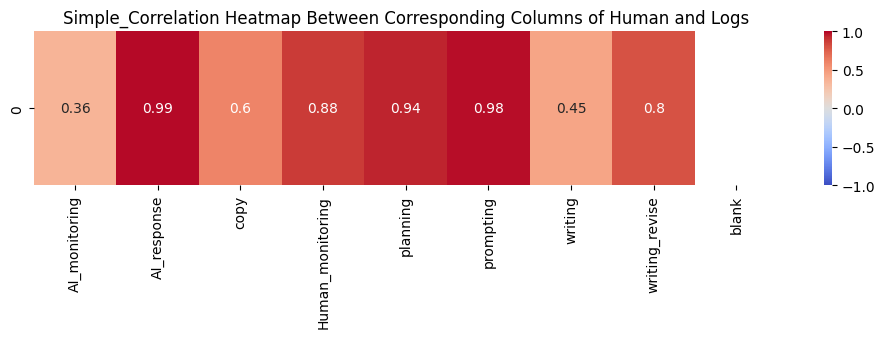

In [ ]:
def calculate_correlations(df1, df2):
    common_columns = df1.columns.intersection(df2.columns)
    results = []

    for col in common_columns:
        corr, p_value = stats.pearsonr(df1[col], df2[col])
        results.append({
            'Column': col,
            'Correlation': corr,
            'P-value': p_value
        })

    return pd.DataFrame(results)

# Calculate correlations
correlation_results = calculate_correlations(human_freq_simple, logs_freq_simple)

# Display results
print(correlation_results)

# Visualization
# plt.figure(figsize=(12, 8))
# sns.scatterplot(data=correlation_results, x='Correlation', y='P-value')

# for i, row in correlation_results.iterrows():
#     plt.annotate(row['Column'], (row['Correlation'], row['P-value']))

# plt.title('Simple_Correlation Coefficient & P-value for Each Column')
# plt.xlabel('Correlation Coefficient')
# plt.ylabel('P-value')
# plt.axhline(y=0.05, color='r', linestyle='--')  # Add a line at p=0.05 for reference
# plt.show()

# Heatmap of correlations
correlation_matrix = human_freq_simple.corrwith(logs_freq_simple)
plt.figure(figsize=(12, 2))
sns.heatmap(correlation_matrix.to_frame().T, annot=True, cmap='coolwarm', vmin=-1, vmax=1, center=0)
plt.title('Simple_Correlation Heatmap Between Corresponding Columns of Human and Logs')
plt.show()

## Complex

             Column  Correlation       P-value
0     AI_monitoring     0.346784  5.597207e-02
1       AI_response     0.997871  6.075159e-36
2              copy     0.682091  2.379364e-05
3  Human_monitoring     0.597581  3.856373e-04
4          planning     0.840841  3.205879e-09
5         prompting     0.981972  1.561403e-22
6           writing     0.464648  8.451713e-03
7    writing_revise     0.639186  1.085577e-04


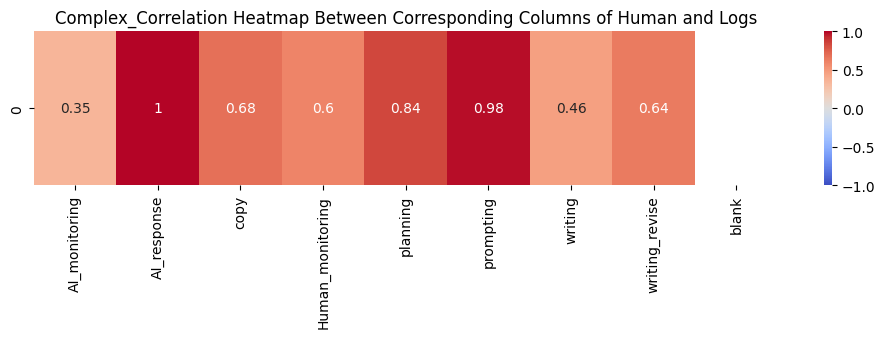

In [ ]:
def calculate_correlations(df1, df2):
    common_columns = df1.columns.intersection(df2.columns)
    results = []

    for col in common_columns:
        corr, p_value = stats.pearsonr(df1[col], df2[col])
        results.append({
            'Column': col,
            'Correlation': corr,
            'P-value': p_value
        })

    return pd.DataFrame(results)

# Calculate correlations
correlation_results = calculate_correlations(human_freq_complex, logs_freq_complex)

# Display results
print(correlation_results)

# Visualization
# plt.figure(figsize=(12, 8))
# sns.scatterplot(data=correlation_results, x='Correlation', y='P-value')

# for i, row in correlation_results.iterrows():
#     plt.annotate(row['Column'], (row['Correlation'], row['P-value']))

# plt.title('Complex_Correlation Coefficient & P-value for Each Column')
# plt.xlabel('Correlation Coefficient')
# plt.ylabel('P-value')
# plt.axhline(y=0.05, color='r', linestyle='--')  # Add a line at p=0.05 for reference
# plt.show()

# Heatmap of correlations
correlation_matrix = human_freq_complex.corrwith(logs_freq_complex)
plt.figure(figsize=(12, 2))
sns.heatmap(correlation_matrix.to_frame().T, annot=True, cmap='coolwarm', vmin=-1, vmax=1, center=0)
plt.title('Complex_Correlation Heatmap Between Corresponding Columns of Human and Logs')
plt.show()

## combined

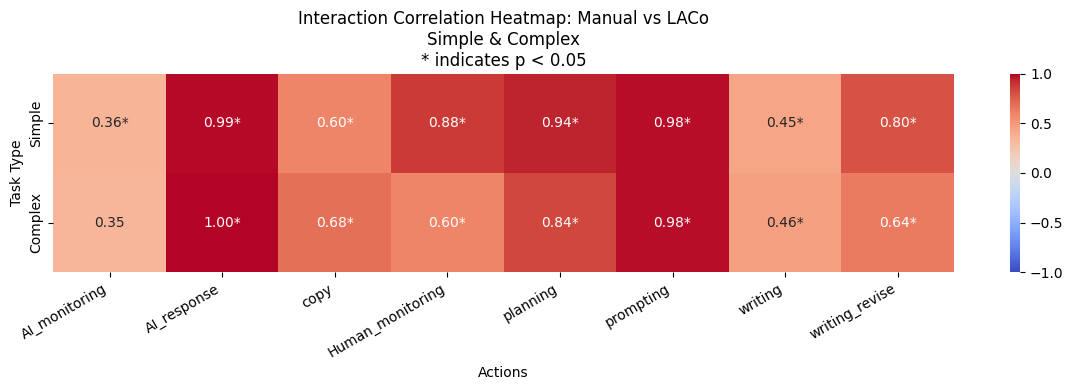

In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from scipy import stats

def calculate_correlations_with_significance(df1, df2):
    common_columns = df1.columns.intersection(df2.columns)
    correlations = {}
    p_values = {}

    for col in common_columns:
        corr, p_value = stats.pearsonr(df1[col], df2[col])
        correlations[col] = corr
        p_values[col] = p_value

    return pd.Series(correlations), pd.Series(p_values)

# Calculate correlations and p-values for both conditions
corr_simple, p_simple = calculate_correlations_with_significance(human_freq_simple, logs_freq_simple)
corr_complex, p_complex = calculate_correlations_with_significance(human_freq_complex, logs_freq_complex)

# Combine correlations
combined_correlations = pd.DataFrame({
    'Simple': corr_simple,
    'Complex': corr_complex
}).T

# Create annotation matrix with significance indicators
def create_annotations(correlations, p_values):
    return [f'{corr:.2f}{"*" if p < 0.05 else ""}'
            for corr, p in zip(correlations, p_values)]

annotations = np.array([
    create_annotations(corr_simple, p_simple),
    create_annotations(corr_complex, p_complex)
])

# Create the heatmap
plt.figure(figsize=(12, 4))
sns.heatmap(combined_correlations,
            annot=annotations,
            cmap='coolwarm',
            vmin=-1,
            vmax=1,
            center=0,
            fmt='')

plt.title('Interaction Correlation Heatmap: Manual vs LACo\nSimple & Complex\n* indicates p < 0.05')
plt.xticks(rotation=30, ha='right')
plt.ylabel('Task Type')
plt.xlabel('Actions')
plt.tight_layout()
plt.show()

# If you want to save the results
# combined_correlations.to_csv('combined_correlations.csv')

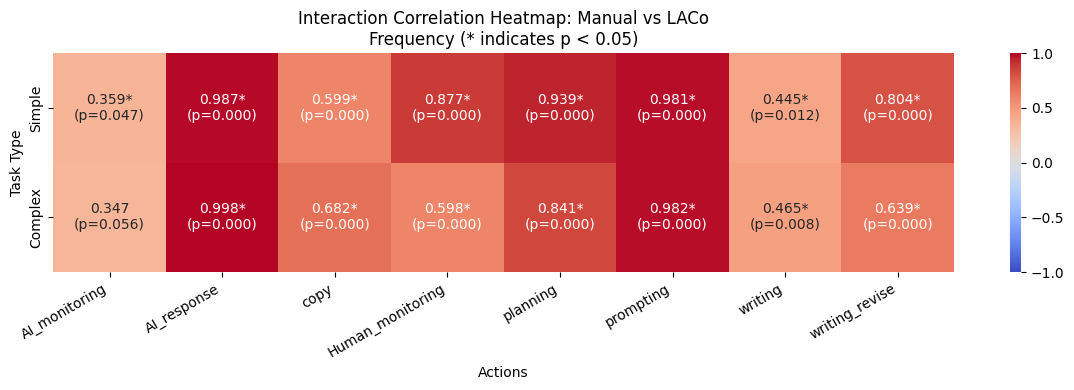

In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from scipy import stats

def calculate_correlations_with_significance(df1, df2):
    common_columns = df1.columns.intersection(df2.columns)
    correlations = {}
    p_values = {}

    for col in common_columns:
        corr, p_value = stats.pearsonr(df1[col], df2[col])
        correlations[col] = corr
        p_values[col] = p_value

    return pd.Series(correlations), pd.Series(p_values)

# Calculate correlations and p-values for both conditions
corr_simple, p_simple = calculate_correlations_with_significance(human_freq_simple, logs_freq_simple)
corr_complex, p_complex = calculate_correlations_with_significance(human_freq_complex, logs_freq_complex)

# Combine correlations
combined_correlations = pd.DataFrame({
    'Simple': corr_simple,
    'Complex': corr_complex
}).T

# Create annotation matrix with both correlations and p-values
def create_annotations(correlations, p_values):
    return [f'{corr:.3f}*\n(p={p:.3f})' if p < 0.05 else f'{corr:.3f}\n(p={p:.3f})'
            for corr, p in zip(correlations, p_values)]

annotations = np.array([
    create_annotations(corr_simple, p_simple),
    create_annotations(corr_complex, p_complex)
])

# Create the heatmap
plt.figure(figsize=(12, 4))

# Create heatmap with adjusted cell size for two-line annotations
sns.heatmap(combined_correlations,
            annot=annotations,
            cmap='coolwarm',
            vmin=-1,
            vmax=1,
            center=0,
            fmt='',
            xticklabels=combined_correlations.columns,
            yticklabels=combined_correlations.index)

# Rotate x-axis labels
plt.xticks(rotation=30, ha='right')

plt.title('Interaction Correlation Heatmap: Manual vs LACo\nFrequency (* indicates p < 0.05)')
plt.ylabel('Task Type')
plt.xlabel('Actions')

# Adjust layout to prevent label cutoff
plt.tight_layout()
plt.show()

# If you want to save the results
# combined_correlations.to_csv('combined_correlations.csv')

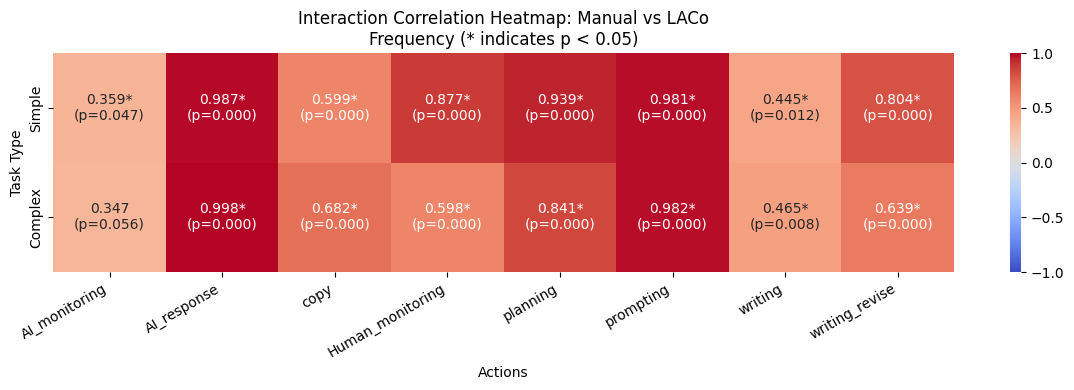


Example of frequency sums for Simple condition:

Human frequencies (first few rows):
             AI_monitoring  AI_response  blank  copy  Human_monitoring  \
participant                                                              
p01                      0            3      2     0                 1   
p02                      3            4     19     1                 5   
p03                      4           16     15     0                 2   
p04                      1            2     21     0                 1   
p05                     11           33     27    17                 4   

             planning  prompting  writing  writing_revise  
participant                                                
p01                 2          3        4               0  
p02                 2          4        7              15  
p03                 7         18       12               4  
p04                 2          2       18               2  
p05                 5         33   

In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from scipy import stats

def calculate_frequency_correlations(df1, df2):
    # Get common columns between the two dataframes
    common_columns = df1.columns.intersection(df2.columns)

    # Calculate frequencies for each participant
    freq1 = df1.groupby('participant')[common_columns].sum()
    freq2 = df2.groupby('participant')[common_columns].sum()

    # Calculate correlations and p-values
    correlations = {}
    p_values = {}

    for col in common_columns:
        if col != 'participant':  # Skip participant column if it exists
            corr, p_value = stats.pearsonr(freq1[col], freq2[col])
            correlations[col] = corr
            p_values[col] = p_value

    return pd.Series(correlations), pd.Series(p_values)

# Calculate frequency correlations for both conditions
corr_simple, p_simple = calculate_frequency_correlations(human_freq_simple, logs_freq_simple)
corr_complex, p_complex = calculate_frequency_correlations(human_freq_complex, logs_freq_complex)

# Combine correlations
combined_correlations = pd.DataFrame({
    'Simple': corr_simple,
    'Complex': corr_complex
}).T

# Create annotation matrix with both correlations and p-values
def create_annotations(correlations, p_values):
    return [f'{corr:.3f}*\n(p={p:.3f})' if p < 0.05 else f'{corr:.3f}\n(p={p:.3f})'
            for corr, p in zip(correlations, p_values)]

annotations = np.array([
    create_annotations(corr_simple, p_simple),
    create_annotations(corr_complex, p_complex)
])

# Create the heatmap
plt.figure(figsize=(12, 4))
sns.heatmap(combined_correlations,
            annot=annotations,
            cmap='coolwarm',
            vmin=-1,
            vmax=1,
            center=0,
            fmt='',
            xticklabels=combined_correlations.columns,
            yticklabels=combined_correlations.index)

# Rotate x-axis labels
plt.xticks(rotation=30, ha='right')

plt.title('Interaction Correlation Heatmap: Manual vs LACo\nFrequency (* indicates p < 0.05)')
plt.ylabel('Task Type')
plt.xlabel('Actions')

# Adjust layout to prevent label cutoff
plt.tight_layout()
plt.show()

# Optional: Display example of summed frequencies
print("\nExample of frequency sums for Simple condition:")
print("\nHuman frequencies (first few rows):")
print(human_freq_simple.groupby('participant').sum().head())
print("\nLog frequencies (first few rows):")
print(logs_freq_simple.groupby('participant').sum().head())

# 상호작용 시간 상관분석

In [5]:
# 비디오 코딩 데이터 불러오기
# xls = pd.read_ExcelFile("/content/drive/MyDrive/2023_인간-AI 협력 역량 진단/8. analysis/Atlas.ti/[ENA용]/HAIcollab_0726.xlsx")
xls = pd.read_excel("/content/drive/MyDrive/2023_인간-AI 협력 역량 진단/8. analysis/Atlas.ti/[ENA용]/HAIcollab_0726.xlsx", sheet_name="Rawdata")

# 로그데이터 불러오기
logs = pd.read_csv('/content/drive/My Drive/2023_인간-AI 협력 역량 진단/8. analysis/combined_logs2.csv')

<ipython-input-5-0711a24ade9f>:6: DtypeWarning: Columns (18) have mixed types. Specify dtype option on import or set low_memory=False.
  logs = pd.read_csv('/content/drive/My Drive/2023_인간-AI 협력 역량 진단/8. analysis/combined_logs2.csv')


In [6]:
logs.columns = ['Unnamed: 0', 'object', 'timestamp', 'eventtype', 'eventdata',
       'taskcomplexity', 'tasktopic', 'participant', 'edit', '내용_정보검색',
       '내용_메타인지', '내용_과제수행', '내용_협상', '내용_기타', '유형_신규', '유형_반복', '유형_추가',
       '정교성', '사회정서적 표현', 'fromstart', 'sentences', 'writing', 'writing_revise', 'changes',
       'planning', 'Human_monitoring', 'AI_monitoring', 'prompting', 'copy', 'paste', 'AI_response', 'fromstart_s',
       'duration_s','내용_메타인지_계획', '내용_메타인지_평가']

In [7]:
logs = logs.drop(['Unnamed: 0','내용_메타인지'], axis=1)

In [8]:
# Columns to drop
columns_to_drop = ['object', 'timestamp', 'eventtype', 'eventdata', 'edit', '내용_정보검색',
                   '내용_과제수행', '내용_협상', '내용_기타', '유형_신규',
                   '유형_반복', '유형_추가', '정교성', '사회정서적 표현', 'fromstart',
                   'sentences', 'changes', 'paste', '내용_메타인지_계획',
                   '내용_메타인지_평가']

# Drop specified columns
logs = logs.drop(columns=columns_to_drop)

In [9]:
xls = xls.drop('tasktopic', axis=1)
xls = xls.drop('blank', axis=1)
logs = logs.drop('tasktopic', axis=1)
xls_simple = xls[xls.taskcomplexity == 'simple']
xls_complex = xls[xls.taskcomplexity == 'complex']
logs_simple = logs[logs.taskcomplexity == 'simple']
logs_complex = logs[logs.taskcomplexity == 'complex']

## filter data

In [10]:
# Columns to check for value 1
columns_to_check = ['AI_monitoring', 'AI_response', 'copy', 'Human_monitoring',
                    'planning', 'prompting', 'writing', 'writing_revise']

# Create a boolean mask for rows where at least one of the specified columns is 1
mask = logs_simple[columns_to_check].eq(1).any(axis=1)

# Filter the dataframe based on the mask
df_filtered = logs_simple[mask]

# Reset index to create a new unique identifier for each row
df_filtered2 = df_filtered.reset_index(drop=True)

# Create a new column 'instance' to number occurrences within each participant
df_filtered2['instance'] = df_filtered2.groupby('participant').cumcount() + 1

df_filtered2['action'] = df_filtered2[columns_to_check].apply(
    lambda row: '+'.join(row.index[row == 1]), axis=1
)

# Reorder columns to put 'participant' and 'instance' first
columns_order = ['participant', 'instance'] + [col for col in df_filtered2.columns if col not in ['participant', 'instance']]
logs_dur_simple1 = df_filtered2[columns_order]
logs_dur_simple = logs_dur_simple1.drop(['taskcomplexity', 'writing',
       'writing_revise', 'planning', 'Human_monitoring', 'AI_monitoring',
       'prompting', 'copy', 'AI_response', 'fromstart_s'], axis=1)

In [11]:
# Columns to check for value 1
columns_to_check = ['AI_monitoring', 'AI_response', 'copy', 'Human_monitoring',
                    'planning', 'prompting', 'writing', 'writing_revise']

# Create a boolean mask for rows where at least one of the specified columns is 1
mask = logs_complex[columns_to_check].eq(1).any(axis=1)

# Filter the dataframe based on the mask
df_filtered = logs_complex[mask]

# Reset index to create a new unique identifier for each row
df_filtered2 = df_filtered.reset_index(drop=True)

# Create a new column 'instance' to number occurrences within each participant
df_filtered2['instance'] = df_filtered2.groupby('participant').cumcount() + 1

df_filtered2['action'] = df_filtered2[columns_to_check].apply(
    lambda row: '+'.join(row.index[row == 1]), axis=1
)

# Reorder columns to put 'participant' and 'instance' first
columns_order = ['participant', 'instance'] + [col for col in df_filtered2.columns if col not in ['participant', 'instance']]
logs_dur_complex1 = df_filtered2[columns_order]
logs_dur_complex = logs_dur_complex1.drop(['taskcomplexity', 'writing',
       'writing_revise', 'planning', 'Human_monitoring', 'AI_monitoring',
       'prompting', 'copy', 'AI_response', 'fromstart_s'], axis=1)

In [12]:
# Columns to check for value 1
columns_to_check = ['AI_monitoring', 'AI_response', 'copy', 'Human_monitoring',
                    'planning', 'prompting', 'writing', 'writing_revise']

# Create a boolean mask for rows where at least one of the specified columns is 1
mask = xls_simple[columns_to_check].eq(1).any(axis=1)

# Filter the dataframe based on the mask
df_filtered = xls_simple[mask]

# Reset index to create a new unique identifier for each row
df_filtered2 = df_filtered.reset_index(drop=True)

# Create a new column 'instance' to number occurrences within each participant
df_filtered2['instance'] = df_filtered2.groupby('participant').cumcount() + 1

df_filtered2['action'] = df_filtered2[columns_to_check].apply(
    lambda row: '+'.join(row.index[row == 1]), axis=1
)

# Reorder columns to put 'participant' and 'instance' first
columns_order = ['participant', 'instance'] + [col for col in df_filtered2.columns if col not in ['participant', 'instance']]
human_dur_simple = df_filtered2[columns_order]
human_dur_simple['duration_s'] = (human_dur_simple['end_time'] - human_dur_simple['start_time'])/1000
human_dur_simple['fromstart_s'] = human_dur_simple['start_time']/1000
human_dur_simple1 = human_dur_simple.drop(['start_time', 'end_time'], axis=1)

human_dur_simple = human_dur_simple1.drop(['taskcomplexity', 'writing',
       'writing_revise', 'planning', 'Human_monitoring', 'AI_monitoring',
       'prompting', 'copy', 'AI_response', 'fromstart_s'], axis=1)

<ipython-input-12-6316bb468b71>:24: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  human_dur_simple['duration_s'] = (human_dur_simple['end_time'] - human_dur_simple['start_time'])/1000
<ipython-input-12-6316bb468b71>:25: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  human_dur_simple['fromstart_s'] = human_dur_simple['start_time']/1000


In [13]:
# Columns to check for value 1
columns_to_check = ['AI_monitoring', 'AI_response', 'copy', 'Human_monitoring',
                    'planning', 'prompting', 'writing', 'writing_revise']

# Create a boolean mask for rows where at least one of the specified columns is 1
mask = xls_complex[columns_to_check].eq(1).any(axis=1)

# Filter the dataframe based on the mask
df_filtered = xls_complex[mask]

# Reset index to create a new unique identifier for each row
df_filtered2 = df_filtered.reset_index(drop=True)

# Create a new column 'instance' to number occurrences within each participant
df_filtered2['instance'] = df_filtered2.groupby('participant').cumcount() + 1

df_filtered2['action'] = df_filtered2[columns_to_check].apply(
    lambda row: '+'.join(row.index[row == 1]), axis=1
)

# Reorder columns to put 'participant' and 'instance' first
columns_order = ['participant', 'instance'] + [col for col in df_filtered2.columns if col not in ['participant', 'instance']]
human_dur_complex = df_filtered2[columns_order]
human_dur_complex['duration_s'] = (human_dur_complex['end_time'] - human_dur_complex['start_time'])/1000
human_dur_complex['fromstart_s'] = human_dur_complex['start_time']/1000
human_dur_complex1 = human_dur_complex.drop(['start_time', 'end_time'], axis=1)

human_dur_complex = human_dur_complex1.drop(['taskcomplexity', 'writing',
       'writing_revise', 'planning', 'Human_monitoring', 'AI_monitoring',
       'prompting', 'copy', 'AI_response', 'fromstart_s'], axis=1)

<ipython-input-13-7cc8dca8faae>:24: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  human_dur_complex['duration_s'] = (human_dur_complex['end_time'] - human_dur_complex['start_time'])/1000
<ipython-input-13-7cc8dca8faae>:25: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  human_dur_complex['fromstart_s'] = human_dur_complex['start_time']/1000


In [14]:
human_dur_simple1['coder'] = 'manual'
logs_dur_simple1['coder'] = 'automatic'
simple_total = pd.concat([human_dur_simple1, logs_dur_simple1], axis=0)
simple_total.to_csv(f"/content/drive/MyDrive/2023_인간-AI 협력 역량 진단/8. analysis/simple_hlcombined.csv", index=False)

human_dur_complex1['coder'] = 'manual'
logs_dur_complex1['coder'] = 'automatic'
complex_total = pd.concat([human_dur_complex1, logs_dur_complex1], axis=0)
complex_total.to_csv(f"/content/drive/MyDrive/2023_인간-AI 협력 역량 진단/8. analysis/complex_hlcombined.csv", index=False)

## correlation 분석

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from scipy import stats

Correlation between actions for manual and automated coding for simple task:
                  correlation       p_value
prompting            0.124474  9.659293e-09
planning+writing          NaN           NaN
copy+planning             NaN           NaN
AI_response          0.017296  4.271408e-01
AI_monitoring        0.009008  6.792067e-01
writing_revise       0.008097  7.100916e-01
copy                -0.003807  8.612465e-01
writing              0.021390  3.260636e-01
Human_monitoring     0.002272  9.169474e-01
planning             0.086324  7.176847e-05


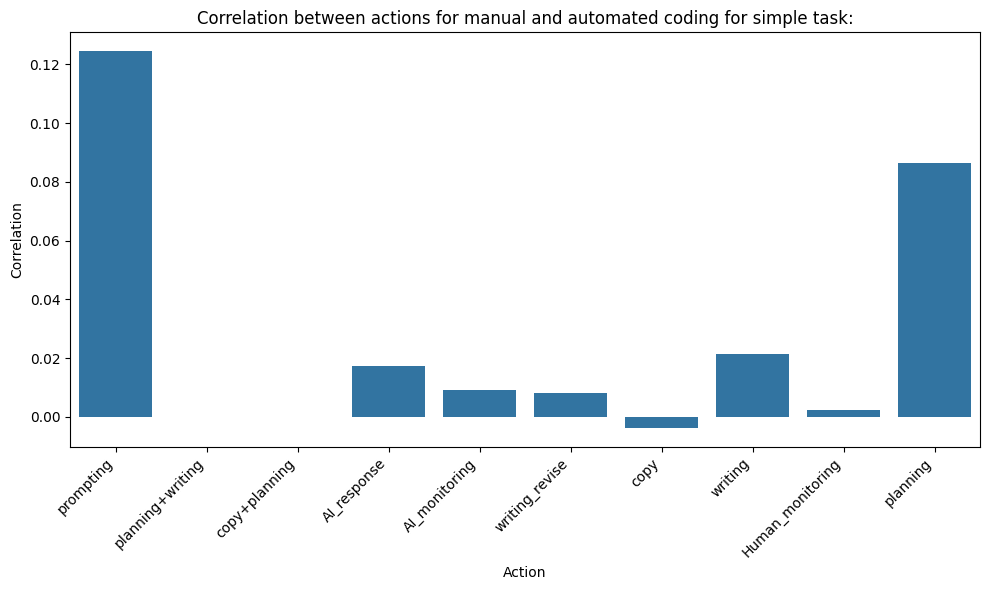

In [15]:
# Assuming you have two dataframes: df1 and df2
# If you need to read them from CSV files, uncomment and modify these lines:
# df1 = pd.read_csv('dataframe1.csv')
# df2 = pd.read_csv('dataframe2.csv')

def prepare_data(df):
    # Create a multi-index with participant and instance
    df_prepared = df.pivot_table(index=['participant', 'instance'],
                                 columns='action',
                                 values='duration_s',
                                 fill_value=0)
    return df_prepared

def compute_correlations(df1, df2):
    # Get all unique actions
    all_actions = list(set(df1.columns) | set(df2.columns))

    # Initialize results dictionary
    correlations = {}

    for action in all_actions:
        # Get data for the action from both dataframes, handling missing columns
        data1 = df1[action] if action in df1.columns else pd.Series(0, index=df1.index)
        data2 = df2[action] if action in df2.columns else pd.Series(0, index=df2.index)

        # Align data based on participant and instance
        aligned_data = pd.concat([data1, data2], axis=1, keys=['df1', 'df2'])
        aligned_data = aligned_data.dropna()

        if not aligned_data.empty and aligned_data['df1'].std() != 0 and aligned_data['df2'].std() != 0:
            # Compute correlation
            corr, p_value = stats.pearsonr(aligned_data['df1'], aligned_data['df2'])
            correlations[action] = {'correlation': corr, 'p_value': p_value}
        else:
            correlations[action] = {'correlation': np.nan, 'p_value': np.nan}

    return pd.DataFrame.from_dict(correlations, orient='index')

# Prepare both dataframes
df1_prepared = prepare_data(human_dur_simple)
df2_prepared = prepare_data(logs_dur_simple)

# Compute the correlations
correlation_results = compute_correlations(df1_prepared, df2_prepared)

# Display the correlation results
print('Correlation between actions for manual and automated coding for simple task:')
print(correlation_results)

# Visualize the correlations
plt.figure(figsize=(10, 6))
sns.barplot(x=correlation_results.index, y='correlation', data=correlation_results)
plt.title('Correlation between actions for manual and automated coding for simple task:')
plt.xlabel('Action')
plt.ylabel('Correlation')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

# If you want to save the correlation results to a CSV file, uncomment this line:
# correlation_results.to_csv('correlation_results.csv')

Correlation between actions for manual and automated coding for complex task:
                  correlation   p_value
prompting            0.055668  0.008437
AI_monitoring        0.046104  0.029181
planning+writing          NaN       NaN
writing_revise       0.017771  0.400738
AI_response          0.000684  0.974214
planning             0.021877  0.300907
Human_monitoring    -0.008378  0.692025
copy                -0.005505  0.794647
writing              0.040677  0.054349
copy+planning             NaN       NaN


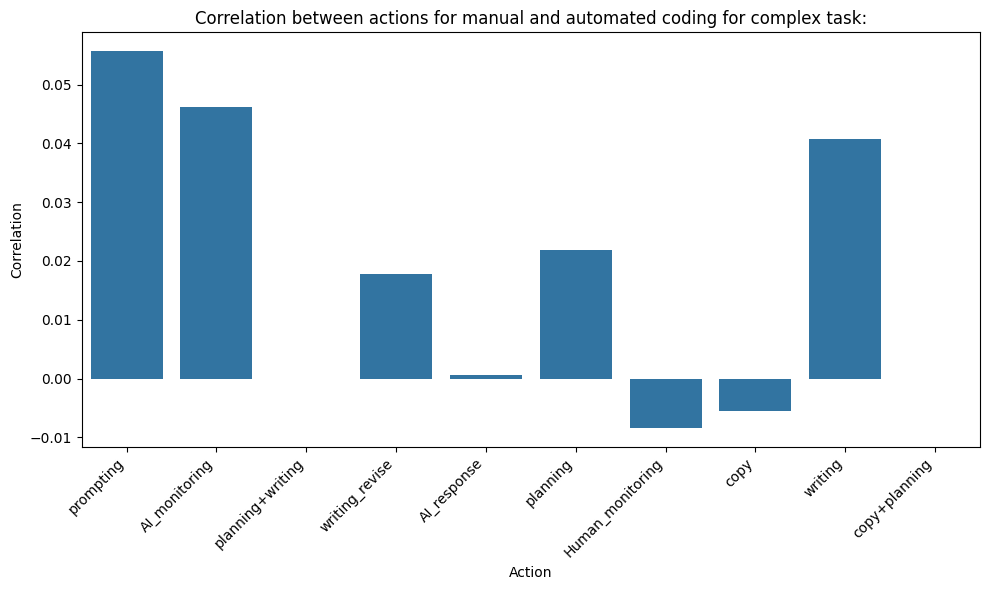

In [ ]:
# Assuming you have two dataframes: df1 and df2
# If you need to read them from CSV files, uncomment and modify these lines:
# df1 = pd.read_csv('dataframe1.csv')
# df2 = pd.read_csv('dataframe2.csv')

def prepare_data(df):
    # Create a multi-index with participant and instance
    df_prepared = df.pivot_table(index=['participant', 'instance'],
                                 columns='action',
                                 values='duration_s',
                                 fill_value=0)
    return df_prepared

def compute_correlations(df1, df2):
    # Get all unique actions
    all_actions = list(set(df1.columns) | set(df2.columns))

    # Initialize results dictionary
    correlations = {}

    for action in all_actions:
        # Get data for the action from both dataframes, handling missing columns
        data1 = df1[action] if action in df1.columns else pd.Series(0, index=df1.index)
        data2 = df2[action] if action in df2.columns else pd.Series(0, index=df2.index)

        # Align data based on participant and instance
        aligned_data = pd.concat([data1, data2], axis=1, keys=['df1', 'df2'])
        aligned_data = aligned_data.dropna()

        if not aligned_data.empty and aligned_data['df1'].std() != 0 and aligned_data['df2'].std() != 0:
            # Compute correlation
            corr, p_value = stats.pearsonr(aligned_data['df1'], aligned_data['df2'])
            correlations[action] = {'correlation': corr, 'p_value': p_value}
        else:
            correlations[action] = {'correlation': np.nan, 'p_value': np.nan}

    return pd.DataFrame.from_dict(correlations, orient='index')

# Prepare both dataframes
df1_prepared = prepare_data(human_dur_complex)
df2_prepared = prepare_data(logs_dur_complex)

# Compute the correlations
correlation_results = compute_correlations(df1_prepared, df2_prepared)

# Display the correlation results
print('Correlation between actions for manual and automated coding for complex task:')
print(correlation_results)

# Visualize the correlations
plt.figure(figsize=(10, 6))
sns.barplot(x=correlation_results.index, y='correlation', data=correlation_results)
plt.title('Correlation between actions for manual and automated coding for complex task:')
plt.xlabel('Action')
plt.ylabel('Correlation')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

# If you want to save the correlation results to a CSV file, uncomment this line:
# correlation_results.to_csv('correlation_results.csv')

Correlations of summed durations between manual and automated coding: simple task
                  correlation       p_value
prompting            0.696428  1.353134e-05
AI_monitoring        0.483026  5.915280e-03
planning+writing          NaN           NaN
writing_revise       0.890344  2.014513e-11
AI_response          0.966327  1.214487e-18
planning             0.884980  3.885455e-11
Human_monitoring     0.492644  4.869567e-03
copy                 0.424469  1.731248e-02
writing              0.908866  1.556669e-12
copy+planning             NaN           NaN


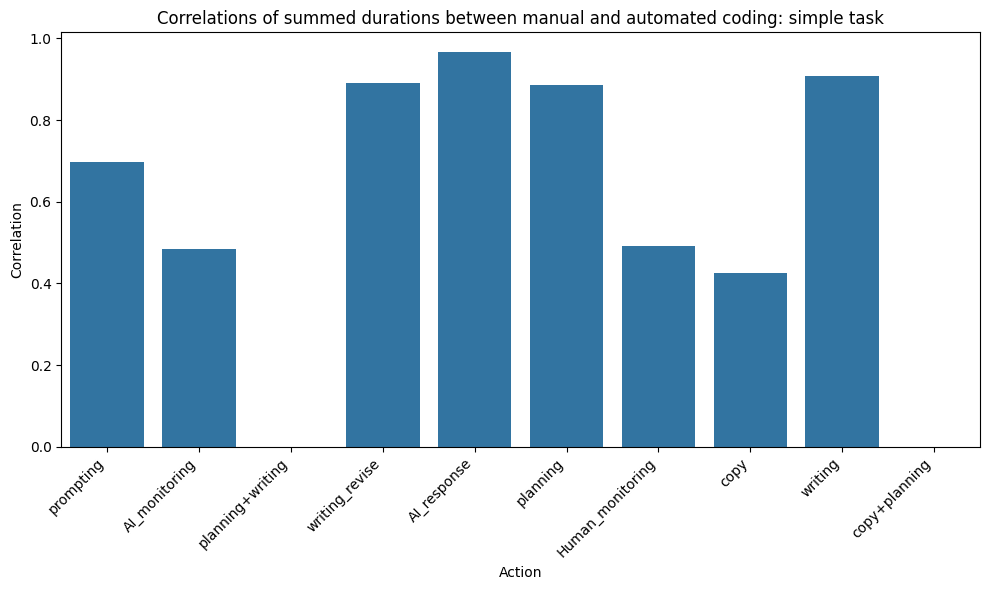

<ipython-input-93-9086781acde1>:58: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all axes decorations.
  plt.tight_layout()


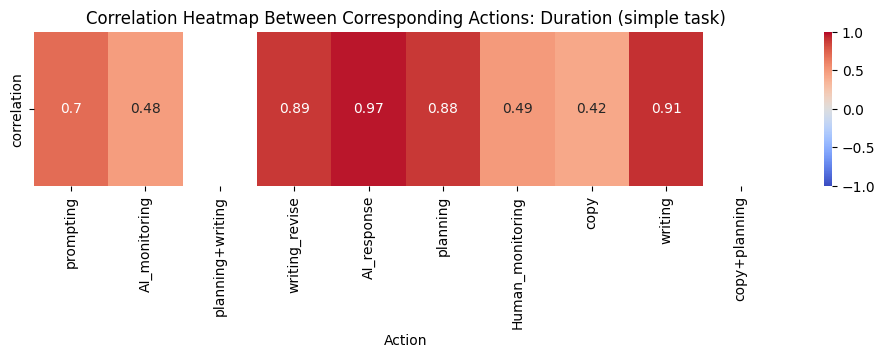

In [ ]:
def prepare_data(df):
    # Sum durations for each participant and action
    df_prepared = df.groupby(['participant', 'action'])['duration_s'].sum().unstack(fill_value=0)
    return df_prepared

def compute_correlations(df1, df2):
    # Get all unique actions
    all_actions = list(set(df1.columns) | set(df2.columns))

    # Initialize results dictionary
    correlations = {}

    for action in all_actions:
        # Get data for the action from both dataframes, handling missing columns
        data1 = df1[action] if action in df1.columns else pd.Series(0, index=df1.index)
        data2 = df2[action] if action in df2.columns else pd.Series(0, index=df2.index)

        # Align data based on participant
        aligned_data = pd.concat([data1, data2], axis=1, keys=['df1', 'df2'])
        aligned_data = aligned_data.dropna()

        if not aligned_data.empty and aligned_data['df1'].std() != 0 and aligned_data['df2'].std() != 0:
            # Compute correlation
            corr, p_value = stats.pearsonr(aligned_data['df1'], aligned_data['df2'])
            correlations[action] = {'correlation': corr, 'p_value': p_value}
        else:
            correlations[action] = {'correlation': np.nan, 'p_value': np.nan}

    return pd.DataFrame.from_dict(correlations, orient='index')

# Prepare both dataframes
df1_prepared = prepare_data(human_dur_simple)
df2_prepared = prepare_data(logs_dur_simple)

# Compute the correlations
correlation_results = compute_correlations(df1_prepared, df2_prepared)

# Display the correlation results
print("Correlations of summed durations between manual and automated coding: simple task")
print(correlation_results)

# Visualize the correlations
plt.figure(figsize=(10, 6))
sns.barplot(x=correlation_results.index, y='correlation', data=correlation_results)
plt.title('Correlations of summed durations between manual and automated coding: simple task')
plt.xlabel('Action')
plt.ylabel('Correlation')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

# Heatmap as a separate plot
plt.figure(figsize=(12, 2))
correlation_matrix = correlation_results['correlation'].to_frame().T
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', vmin=-1, vmax=1, center=0)
plt.title('Correlation Heatmap Between Corresponding Actions: Duration (simple task)')
plt.xlabel('Action')
plt.tight_layout()
plt.show()

# If you want to save the correlation results to a CSV file, uncomment this line:
# correlation_results.to_csv('correlation_results.csv')

Correlations of summed durations between manual and automated coding: complex task
                  correlation       p_value
prompting            0.824166  1.213412e-08
AI_monitoring        0.525661  2.390199e-03
planning+writing          NaN           NaN
writing_revise       0.771840  3.689985e-07
AI_response          0.927843  5.968707e-14
planning             0.989875  3.820085e-26
Human_monitoring     0.278665  1.290056e-01
copy                 0.693373  1.530155e-05
writing              0.948497  5.135435e-16
copy+planning             NaN           NaN


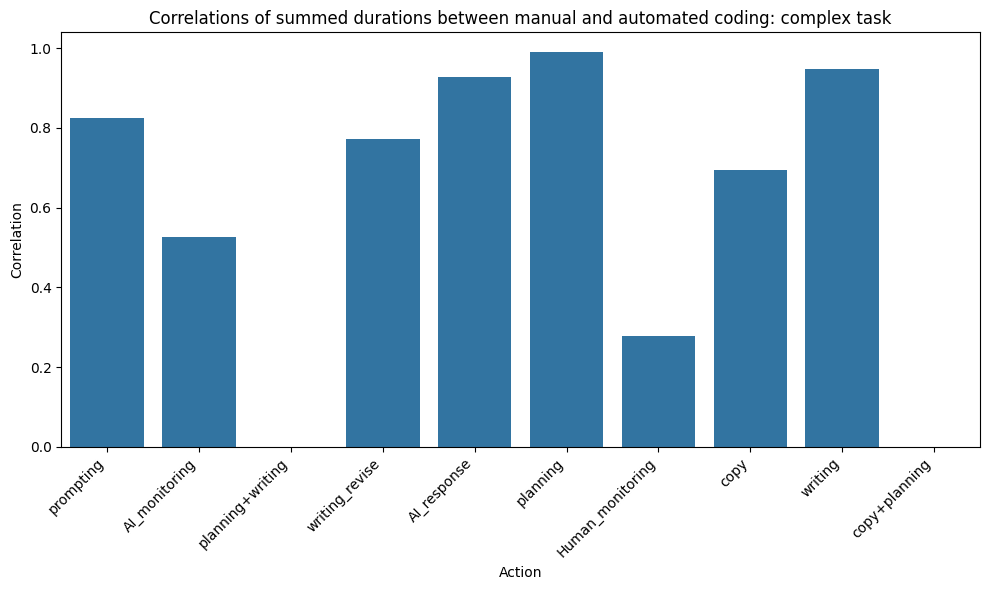

<ipython-input-94-a143e695a974>:58: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all axes decorations.
  plt.tight_layout()


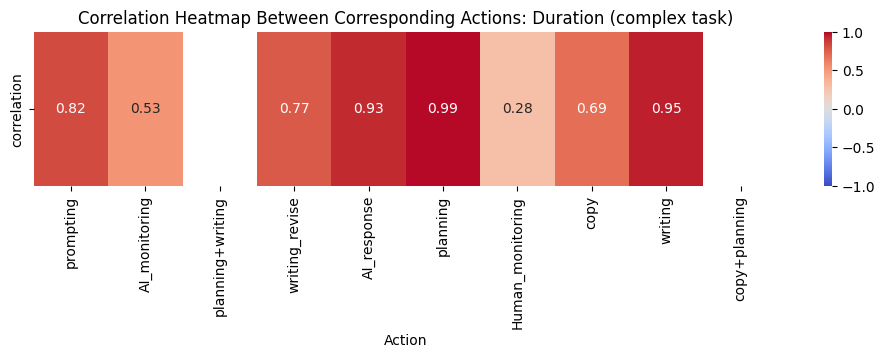

In [ ]:
def prepare_data(df):
    # Sum durations for each participant and action
    df_prepared = df.groupby(['participant', 'action'])['duration_s'].sum().unstack(fill_value=0)
    return df_prepared

def compute_correlations(df1, df2):
    # Get all unique actions
    all_actions = list(set(df1.columns) | set(df2.columns))

    # Initialize results dictionary
    correlations = {}

    for action in all_actions:
        # Get data for the action from both dataframes, handling missing columns
        data1 = df1[action] if action in df1.columns else pd.Series(0, index=df1.index)
        data2 = df2[action] if action in df2.columns else pd.Series(0, index=df2.index)

        # Align data based on participant
        aligned_data = pd.concat([data1, data2], axis=1, keys=['df1', 'df2'])
        aligned_data = aligned_data.dropna()

        if not aligned_data.empty and aligned_data['df1'].std() != 0 and aligned_data['df2'].std() != 0:
            # Compute correlation
            corr, p_value = stats.pearsonr(aligned_data['df1'], aligned_data['df2'])
            correlations[action] = {'correlation': corr, 'p_value': p_value}
        else:
            correlations[action] = {'correlation': np.nan, 'p_value': np.nan}

    return pd.DataFrame.from_dict(correlations, orient='index')

# Prepare both dataframes
df1_prepared = prepare_data(human_dur_complex)
df2_prepared = prepare_data(logs_dur_complex)

# Compute the correlations
correlation_results = compute_correlations(df1_prepared, df2_prepared)

# Display the correlation results
print("Correlations of summed durations between manual and automated coding: complex task")
print(correlation_results)

# Visualize the correlations
plt.figure(figsize=(10, 6))
sns.barplot(x=correlation_results.index, y='correlation', data=correlation_results)
plt.title('Correlations of summed durations between manual and automated coding: complex task')
plt.xlabel('Action')
plt.ylabel('Correlation')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

# Heatmap as a separate plot
plt.figure(figsize=(12, 2))
correlation_matrix = correlation_results['correlation'].to_frame().T
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', vmin=-1, vmax=1, center=0)
plt.title('Correlation Heatmap Between Corresponding Actions: Duration (complex task)')
plt.xlabel('Action')
plt.tight_layout()
plt.show()
# If you want to save the correlation results to a CSV file, uncomment this line:
# correlation_results.to_csv('correlation_results.csv')

## correlation of summed average

In [ ]:
human_dur_simple1.head()

,participant,instance,taskcomplexity,AI_monitoring,AI_response,copy,Human_monitoring,planning,prompting,writing,writing_revise,action,duration_s,fromstart_s,coder
0,p01,1,simple,0,0,0,0,1,0,0,0,planning,27.341,27.471,manual
1,p01,2,simple,0,0,0,0,0,1,0,0,prompting,14.887,54.812,manual
2,p01,3,simple,0,1,0,0,0,0,0,0,AI_response,18.887,69.912,manual
3,p01,4,simple,0,0,0,0,0,1,0,0,prompting,5.111,88.799,manual
4,p01,5,simple,0,1,0,0,0,0,0,0,AI_response,22.010,93.910,manual


In [18]:
def prepare_data(df):
    # Sum durations for each participant and action
    df_prepared = df.groupby(['participant', 'action'])['duration_s'].sum().unstack(fill_value=0)
    return df_prepared

df_human_simple = prepare_data(human_dur_simple)
df_human_complex = prepare_data(human_dur_complex)
df_logs_simple = prepare_data(logs_dur_simple)
df_logs_complex = prepare_data(logs_dur_complex)

df_logs_complex.head()

action,AI_monitoring,AI_response,Human_monitoring,copy,copy+planning,planning,planning+writing,prompting,writing,writing_revise
participant,,,,,,,,,,
p01,3.34100,27.44171,0.000,0.00000,0.0,0.56800,0.0,6.81424,504.43395,24.18400
p02,42.35320,136.72254,2.351,0.00000,0.0,82.23472,0.0,109.39965,257.57900,474.12966
p03,25.89412,81.61606,15.295,5.01700,0.0,198.92312,0.0,27.33156,450.20800,143.05200
p04,64.35394,244.12715,9.540,0.00000,0.0,28.49000,0.0,101.77779,573.63800,44.95100
p05,87.04146,452.61001,9.690,41.10909,0.0,27.26900,0.0,488.88199,0.00000,286.53900


In [19]:
# First, let's create a function that can handle this for any two similar datasets
def average_datasets(df1, df2):
    # Ensure both dataframes have the same shape
    if df1.shape != df2.shape:
        raise ValueError("Datasets must have the same dimensions")

    # Calculate the average
    averaged_df = (df1 + df2) / 2

    return averaged_df

# Example usage with your data:

# Convert string data to DataFrames
df1 = df_human_simple
df2 = df_human_complex

df3 = df_logs_simple
df4 = df_logs_complex

# Calculate average
result = average_datasets(df1, df2)
result2 = average_datasets(df3, df4)

# If you want to save the result
df_human_dur = result
df_logs_dur = result2
result.to_csv('/content/drive/MyDrive/2023_인간-AI 협력 역량 진단/8. analysis/human_dur_averaged.csv')
result2.to_csv('/content/drive/MyDrive/2023_인간-AI 협력 역량 진단/8. analysis/logs_dur_averaged.csv')

# Display the result
result.head()

action,AI_monitoring,AI_response,Human_monitoring,copy,planning,prompting,writing,writing_revise
participant,,,,,,,,
p01,0.0000,37.0895,1.7850,0.0000,18.8125,17.0310,603.7310,0.0000
p02,8.9305,160.9850,82.8325,16.8670,81.0310,79.3360,197.5545,477.0805
p03,10.3955,157.7805,32.1685,3.5050,183.5745,119.9255,719.6755,110.6500
p04,38.6685,71.7725,10.1070,0.0000,8.9310,53.5510,379.8550,3.1250
p05,92.1680,431.7285,19.6220,189.6345,19.2815,504.8860,121.9200,420.8470


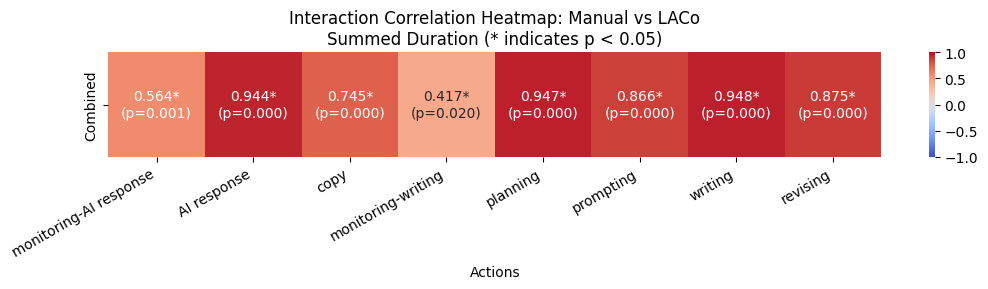

In [21]:
def calculate_correlations_with_significance(df1, df2):
    common_columns = df1.columns.intersection(df2.columns)
    correlations = {}
    p_values = {}

    for col in common_columns:
        corr, p_value = stats.pearsonr(df1[col], df2[col])
        correlations[col] = corr
        p_values[col] = p_value

    return pd.Series(correlations), pd.Series(p_values)

# Calculate correlations and p-values for both conditions
corr_combined, p_combined = calculate_correlations_with_significance(df_human_dur, df_logs_dur)

# Combine correlations
combined_correlations = pd.DataFrame({
    'Combined': corr_combined,
}).T

# Define the desired column order
column_order = ["AI_monitoring", "AI_response", "copy", "Human_monitoring", "planning", "prompting", "writing", "writing_revise"]

# Define the new column names
new_column_names = ["monitoring-AI response", "AI response", "copy", "monitoring-writing", "planning", "prompting", "writing", "revising"]

# Create a mapping from old names to new names
name_mapping = dict(zip(column_order, new_column_names))

# Reorder columns in the correlations DataFrame
combined_correlations = combined_correlations[column_order]

# Create annotation matrix with both correlations and p-values
def create_annotations(correlations, p_values):
    return [f'{corr:.3f}*\n(p={p:.3f})' if p < 0.05 else f'{corr:.3f}\n(p={p:.3f})'
            for corr, p in zip(correlations, p_values)]

# Reorder p_values to match the column order
p_combined_ordered = p_combined[column_order]

annotations = np.array([
    create_annotations(combined_correlations.iloc[0], p_combined_ordered),
])

# Create the heatmap
plt.figure(figsize=(11, 3))

# Create heatmap with new column names
sns.heatmap(combined_correlations,
            annot=annotations,
            cmap='coolwarm',
            vmin=-1,
            vmax=1,
            center=0,
            fmt='',
            xticklabels=new_column_names,
            yticklabels=combined_correlations.index,
            cbar_kws={'ticks': [-1, -0.5, 0, 0.5, 1]})

# Rotate x-axis labels
plt.xticks(rotation=30, ha='right')

plt.title('Interaction Correlation Heatmap: Manual vs LACo\nSummed Duration (* indicates p < 0.05)')
plt.xlabel('Actions')

# Adjust layout to prevent label cutoff
plt.tight_layout()
plt.show()

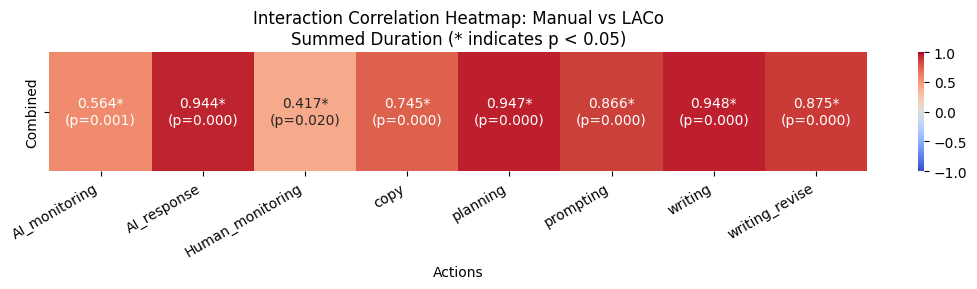

In [ ]:
def calculate_correlations_with_significance(df1, df2):
    common_columns = df1.columns.intersection(df2.columns)
    correlations = {}
    p_values = {}

    for col in common_columns:
        corr, p_value = stats.pearsonr(df1[col], df2[col])
        correlations[col] = corr
        p_values[col] = p_value

    return pd.Series(correlations), pd.Series(p_values)

# Calculate correlations and p-values for both conditions
corr_combined, p_combined = calculate_correlations_with_significance(df_human_dur, df_logs_dur)

# Combine correlations
combined_correlations = pd.DataFrame({
    'Combined': corr_combined,
}).T

# Create annotation matrix with both correlations and p-values
def create_annotations(correlations, p_values):
    return [f'{corr:.3f}*\n(p={p:.3f})' if p < 0.05 else f'{corr:.3f}\n(p={p:.3f})'
            for corr, p in zip(correlations, p_values)]

annotations = np.array([
    create_annotations(corr_combined, p_combined),
])

# Create the heatmap
plt.figure(figsize=(11, 3))

# Create heatmap with adjusted cell size for two-line annotations
sns.heatmap(combined_correlations,
            annot=annotations,
            cmap='coolwarm',
            vmin=-1,
            vmax=1,
            center=0,
            fmt='',
            xticklabels=combined_correlations.columns,
            yticklabels=combined_correlations.index)

# Rotate x-axis labels
plt.xticks(rotation=30, ha='right')

plt.title('Interaction Correlation Heatmap: Manual vs LACo\nSummed Duration (* indicates p < 0.05)')
#plt.ylabel('Task Type')
plt.xlabel('Actions')

# Adjust layout to prevent label cutoff
plt.tight_layout()
plt.show()

## total correlation of summed duration

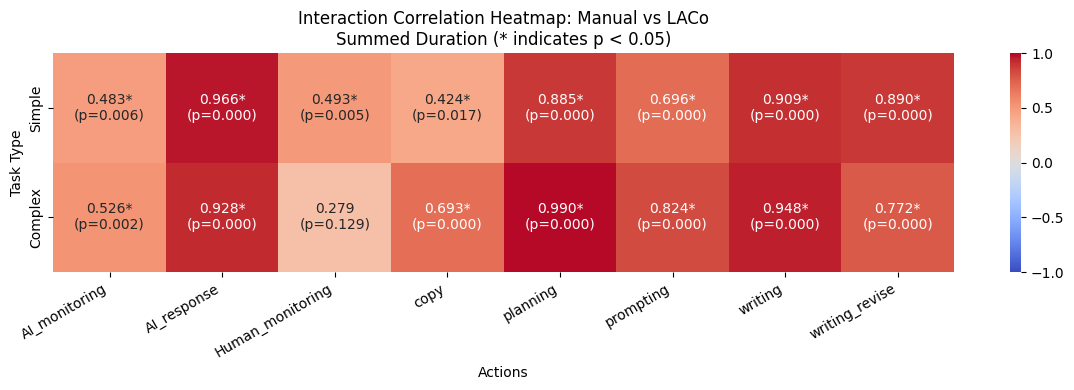

In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from scipy import stats

def prepare_data(df):
    # Sum durations for each participant and action
    df_prepared = df.groupby(['participant', 'action'])['duration_s'].sum().unstack(fill_value=0)
    return df_prepared

# Prepare both dataframes
human_dur_simple1 = prepare_data(human_dur_simple)
human_dur_complex1 = prepare_data(human_dur_complex)
logs_dur_simple1 = prepare_data(logs_dur_simple)
logs_dur_complex1 = prepare_data(logs_dur_complex)

def calculate_correlations_with_significance(df1, df2):
    common_columns = df1.columns.intersection(df2.columns)
    correlations = {}
    p_values = {}

    for col in common_columns:
        corr, p_value = stats.pearsonr(df1[col], df2[col])
        correlations[col] = corr
        p_values[col] = p_value

    return pd.Series(correlations), pd.Series(p_values)

# Calculate correlations and p-values for both conditions
corr_simple, p_simple = calculate_correlations_with_significance(human_dur_simple1, logs_dur_simple1)
corr_complex, p_complex = calculate_correlations_with_significance(human_dur_complex1, logs_dur_complex1)

# Combine correlations
combined_correlations = pd.DataFrame({
    'Simple': corr_simple,
    'Complex': corr_complex
}).T

# Create annotation matrix with both correlations and p-values
def create_annotations(correlations, p_values):
    return [f'{corr:.3f}*\n(p={p:.3f})' if p < 0.05 else f'{corr:.3f}\n(p={p:.3f})'
            for corr, p in zip(correlations, p_values)]

annotations = np.array([
    create_annotations(corr_simple, p_simple),
    create_annotations(corr_complex, p_complex)
])

# Create the heatmap
plt.figure(figsize=(12, 4))

# Create heatmap with adjusted cell size for two-line annotations
sns.heatmap(combined_correlations,
            annot=annotations,
            cmap='coolwarm',
            vmin=-1,
            vmax=1,
            center=0,
            fmt='',
            xticklabels=combined_correlations.columns,
            yticklabels=combined_correlations.index)

# Rotate x-axis labels
plt.xticks(rotation=30, ha='right')

plt.title('Interaction Correlation Heatmap: Manual vs LACo\nSummed Duration (* indicates p < 0.05)')
plt.ylabel('Task Type')
plt.xlabel('Actions')

# Adjust layout to prevent label cutoff
plt.tight_layout()
plt.show()

# If you want to save the results
# combined_correlations.to_csv('combined_correlations.csv')

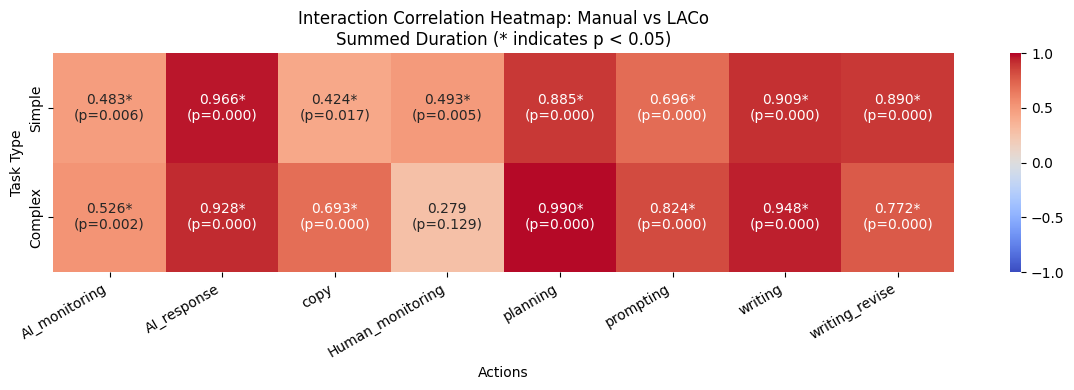

In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from scipy import stats

# Define the desired column order
column_order = ['AI_monitoring', 'AI_response', 'copy', 'Human_monitoring',
                'planning', 'prompting', 'writing', 'writing_revise']

def prepare_data(df):
    # Sort the dataframe by participant and action first
    df_sorted = df.sort_values(['participant', 'action'])

    # Sum durations for each participant and action
    df_prepared = df_sorted.groupby(['participant', 'action'])['duration_s'].sum().unstack(fill_value=0)

    # Reorder columns according to specified order
    df_prepared = df_prepared.reindex(columns=column_order)

    return df_prepared

def calculate_correlations_with_significance(df1, df2):
    # Use the predefined column order for common columns
    common_columns = [col for col in column_order if col in df1.columns and col in df2.columns]
    correlations = {}
    p_values = {}

    for col in common_columns:
        corr, p_value = stats.pearsonr(df1[col], df2[col])
        correlations[col] = corr
        p_values[col] = p_value

    return pd.Series(correlations), pd.Series(p_values)

# Prepare both dataframes
human_dur_simple1 = prepare_data(human_dur_simple)
human_dur_complex1 = prepare_data(human_dur_complex)
logs_dur_simple1 = prepare_data(logs_dur_simple)
logs_dur_complex1 = prepare_data(logs_dur_complex)

# Calculate correlations and p-values for both conditions
corr_simple, p_simple = calculate_correlations_with_significance(human_dur_simple1, logs_dur_simple1)
corr_complex, p_complex = calculate_correlations_with_significance(human_dur_complex1, logs_dur_complex1)

# Combine correlations and use custom column order
combined_correlations = pd.DataFrame({
    'Simple': corr_simple,
    'Complex': corr_complex
}).T
combined_correlations = combined_correlations.reindex(columns=column_order)

# Create annotation matrix with both correlations and p-values
def create_annotations(correlations, p_values):
    return [f'{corr:.3f}*\n(p={p:.3f})' if p < 0.05 else f'{corr:.3f}\n(p={p:.3f})'
            for corr, p in zip(correlations, p_values)]

annotations = np.array([
    create_annotations(corr_simple, p_simple),
    create_annotations(corr_complex, p_complex)
])

# Create the heatmap
plt.figure(figsize=(12, 4))

# Create heatmap with adjusted cell size for two-line annotations
sns.heatmap(combined_correlations,
            annot=annotations,
            cmap='coolwarm',
            vmin=-1,
            vmax=1,
            center=0,
            fmt='',
            xticklabels=combined_correlations.columns,
            yticklabels=combined_correlations.index)

# Rotate x-axis labels
plt.xticks(rotation=30, ha='right')

plt.title('Interaction Correlation Heatmap: Manual vs LACo\nSummed Duration (* indicates p < 0.05)')
plt.ylabel('Task Type')
plt.xlabel('Actions')

# Adjust layout to prevent label cutoff
plt.tight_layout()
plt.show()

### simple

In [ ]:
def calculate_correlations(df1, df2):
    common_columns = df1.columns.intersection(df2.columns)
    results = []

    for col in common_columns:
        corr, p_value = stats.pearsonr(df1[col], df2[col])
        results.append({
            'Column': col,
            'Correlation': corr,
            'P-value': p_value
        })

    return pd.DataFrame(results)

# Calculate correlations
correlation_results = calculate_correlations(human_dur_simple, logs_dur_simple)

# Display results
print(correlation_results)

# Heatmap of correlations
correlation_matrix = human_dur_simple.corrwith(logs_dur_simple)
plt.figure(figsize=(12, 2))
sns.heatmap(correlation_matrix.to_frame().T, annot=True, cmap='coolwarm', vmin=-1, vmax=1, center=0)
plt.title('Simple_Correlation Heatmap Between Corresponding Columns of Human and Logs')
plt.show()

### complex

In [ ]:
def calculate_correlations(df1, df2):
    common_columns = df1.columns.intersection(df2.columns)
    results = []

    for col in common_columns:
        corr, p_value = stats.pearsonr(df1[col], df2[col])
        results.append({
            'Column': col,
            'Correlation': corr,
            'P-value': p_value
        })

    return pd.DataFrame(results)

# Calculate correlations
correlation_results = calculate_correlations(human_dur_complex, logs_dur_complex)

# Display results
print(correlation_results)

# Heatmap of correlations
correlation_matrix = human_dur_complex.corrwith(logs_dur_complex)
plt.figure(figsize=(12, 2))
sns.heatmap(correlation_matrix.to_frame().T, annot=True, cmap='coolwarm', vmin=-1, vmax=1, center=0)
plt.title('Complex_Correlation Heatmap Between Corresponding Columns of Human and Logs')
plt.show()

# 비디오 코딩 데이터 행동지표

In [ ]:
# 비디오 코딩 데이터 행동지표 결과
participantid = []
taskcomplexity1 = []
tasktopic1 = []

#engagement
engagement_prompts = []
engagement_AImonitoring = []
# engagement_newprompt = []

# #fluency
# fluency_functions = []
# fluency_prompt_mean = []
# fluency_prompt_std = []
# fluency_repeatr = []

# #teambond
# teambond_repeatr2 = []
# teambond_socioemotional_mean = []
# teambond_socioemotional_std = []

# #social interdependence
# interdependence_addprompt = []
# interdependence_negotiationprompt = []

#task regulation
regulation_plan = []
# regulation_metacognition = []
# regulation_information = []

for p in plist1:
  #create dataframes
  df_simple = xls[(xls.participant == p) & (xls.taskcomplexity == 'simple')]
  df_complex = xls[(xls.participant == p) & (xls.taskcomplexity == 'complex')]

  ###basic###
  participantid.append(df_simple['participant'].unique())
  taskcomplexity1.append(df_simple['taskcomplexity'].unique()[0])
  tasktopic1.append(df_simple['tasktopic'].unique())
  participantid.append(df_complex['participant'].unique())
  taskcomplexity1.append(df_complex['taskcomplexity'].unique()[0])
  tasktopic1.append(df_complex['tasktopic'].unique())

  ###참여도###
  # 빈도
  prompts = len(df_simple[df_simple['prompting'] == 1]) # 프롬프트의 개수
  AImonitoring = len(df_simple[df_simple['AI_monitoring'] == 1]) # AI 점검 횟수
  # newprompt = len(df_simple[df_simple['유형_신규'] == 1]) # 프롬프트 유형(신규)의 횟수
  #append
  engagement_prompts.append(prompts)
  engagement_AImonitoring.append(AImonitoring)
  # engagement_newprompt.append(newprompt)
  # 빈도2
  prompts2 = len(df_complex[df_complex['prompting'] == 1]) # 프롬프트의 개수
  AImonitoring2 = len(df_complex[df_complex['AI_monitoring'] == 1]) # AI 점검 횟수
  # newprompt2 = len(df_complex[df_complex['유형_신규'] == 1]) # 프롬프트 유형(신규)의 횟수
  #append2
  engagement_prompts.append(prompts2)
  engagement_AImonitoring.append(AImonitoring2)
  # engagement_newprompt.append(newprompt2)

  ###능숙도###
  # 빈도
  # functions = len(df_simple[df_simple['edit'] == 'TRUE'])
  # prompt_fluency_mean = df_simple.정교성[df_simple['prompting'] == 1].astype(float).mean()
  # prompt_fluency_std = df_simple.정교성[df_simple['prompting'] == 1].astype(float).std()
  # Rrepeat = len(df_simple[df_simple['유형_반복'] == 1])
  # #append
  # fluency_functions.append(functions)
  # fluency_prompt_mean.append(prompt_fluency_mean)
  # fluency_prompt_std.append(prompt_fluency_std)
  # fluency_repeatr.append(Rrepeat)
  # # 빈도2
  # functions2 = len(df_complex[df_complex['edit'] == 'TRUE'])
  # prompt_fluency_mean2 = df_complex.정교성[df_complex['prompting'] == 1].astype(float).mean()
  # prompt_fluency_std2 = df_complex.정교성[df_complex['prompting'] == 1].astype(float).std()
  # Rrepeat2 = len(df_complex[df_complex['유형_반복'] == 1])
  # #append
  # fluency_functions.append(functions2)
  # fluency_prompt_mean.append(prompt_fluency_mean2)
  # fluency_prompt_std.append(prompt_fluency_std2)
  # fluency_repeatr.append(Rrepeat2)

  ###결속력###
  # 빈도
  # Rrepeat2 = len(df_simple[df_simple['유형_반복'] == 1])/newprompt # 신규 프롬프트 대비 프롬프트 유형 비율
  # socioemotional_mean = df_simple['사회정서적 표현'][df_simple['프롬프트'] == 1].astype(float).mean()
  # socioemotional_std = df_simple['사회정서적 표현'][df_simple['프롬프트'] == 1].astype(float).std()
  # #append
  # teambond_repeatr2.append(Rrepeat2)
  # teambond_socioemotional_mean.append(socioemotional_mean)
  # teambond_socioemotional_std.append(socioemotional_std)
  # # 빈도2
  # Rrepeat22 = len(df_complex[df_complex['유형_반복'] == 1])/newprompt # 신규 프롬프트 대비 프롬프트 유형 비율
  # socioemotional_mean2 = df_complex['사회정서적 표현'][df_complex['프롬프트'] == 1].astype(float).mean()
  # socioemotional_std2 = df_complex['사회정서적 표현'][df_complex['프롬프트'] == 1].astype(float).std()
  # #append2
  # teambond_repeatr2.append(Rrepeat22)
  # teambond_socioemotional_mean.append(socioemotional_mean2)
  # teambond_socioemotional_std.append(socioemotional_std2)

  ###상호의존###
  # 빈도
  # addprompt = len(df_simple[df_simple['유형_추가'] == 1]) # 추가 프롬프트의 횟수
  # negotiationprompt = len(df_simple[df_simple['내용_협상'] == 1]) # 협상 프롬프트의 횟수
  # #append
  # interdependence_addprompt.append(addprompt)
  # interdependence_negotiationprompt.append(negotiationprompt)
  # # 빈도
  # addprompt2 = len(df_complex[df_complex['유형_추가'] == 1]) # 추가 프롬프트의 횟수
  # negotiationprompt2 = len(df_complex[df_complex['내용_협상'] == 1]) # 협상 프롬프트의 횟수
  # #append
  # interdependence_addprompt.append(addprompt2)
  # interdependence_negotiationprompt.append(negotiationprompt2)

  ###과제조절###
  # 빈도
  plan = len(df_simple[df_simple['planning'] == 1]) # planning의 횟수
  # metacognition = len(df_simple[df_simple['내용_메타인지'] == 1]) # 메타인지 프롬프트의 횟수
  # information = len(df_simple[df_simple['내용_정보검색'] == 1]) # 정보검색 프롬프트의 횟수
  #append
  regulation_plan.append(plan)
  # regulation_metacognition.append(metacognition)
  # regulation_information.append(information)
  # 빈도
  plan2 = len(df_complex[df_complex['planning'] == 1]) # planning의 횟수
  # metacognition2 = len(df_complex[df_complex['내용_메타인지'] == 1]) # 메타인지 프롬프트의 횟수
  # information2 = len(df_complex[df_complex['내용_정보검색'] == 1]) # 정보검색 프롬프트의 횟수
  #append
  regulation_plan.append(plan2)
  # regulation_metacognition.append(metacognition2)
  # regulation_information.append(information2)

# 데이터프레임으로 합치기
df_video_total = pd.DataFrame(
    {'participant':participantid,
     'taskcomplexity':taskcomplexity1,
     'tasktopic':tasktopic1,
     'engagement_prompts':engagement_prompts,
     'engagement_AImonitoring':engagement_AImonitoring,
    #  'engagement_newprompt':engagement_newprompt,
    #  'fluency_functions':fluency_functions,
    #  'fluency_prompt_mean':fluency_prompt_mean,
    #  'fluency_prompt_std':fluency_prompt_std,
    #  'fluency_repeatr':fluency_repeatr,
    #  'teambond_repeatr2':teambond_repeatr2,
    #  'teambond_socioemotional_mean':teambond_socioemotional_mean,
    #  'teambond_socioemotional_std':teambond_socioemotional_std,
    #  'interdependence_addprompt':interdependence_addprompt,
    #  'interdependence_negotiationprompt':interdependence_negotiationprompt,
     'regulation_plan':regulation_plan
    #  'regulation_metacognition':regulation_metacognition,
    #  'regulation_information':regulation_information
     }
)
df_video_total.to_csv("/content/drive/MyDrive/2023_인간-AI 협력 역량 진단/8. analysis/video_total.csv", index=False)
df_video_total

,participant,taskcomplexity,tasktopic,engagement_prompts,engagement_AImonitoring,regulation_plan
0,[p01],simple,[fossilfuel],3,0,2
1,[p01],complex,[freetrade],2,0,0
2,[p02],simple,[freetrade],4,3,2
3,[p02],complex,[fossilfuel],8,2,2
4,[p03],simple,[freetrade],18,4,7
...,...,...,...,...,...,...
57,[p30],complex,[fossilfuel],9,15,1
58,[p31],simple,[freetrade],8,9,5
59,[p31],complex,[fossilfuel],7,5,6
60,[p32],simple,[fossilfuel],10,16,14


## 비디오 코딩_시각화

In [ ]:
# fig = px.histogram(df_video_total, x='engagement_prompts', color='taskcomplexity', barmode='group',nbins=20)
fig = px.violin(df_video_total, x='engagement_prompts', color='taskcomplexity')
fig.show()

In [ ]:
# fig = px.histogram(df_video_total, x='engagement_AImonitoring', color='taskcomplexity', barmode='group',nbins=20)
fig = px.violin(df_video_total, x='engagement_AImonitoring', color='taskcomplexity')
fig.show()

In [ ]:
# fig = px.histogram(df_video_total, x='regulation_plan', color='taskcomplexity', barmode='group',nbins=20)
fig = px.violin(df_video_total, x='regulation_plan', color='taskcomplexity')
fig.show()

# 비디오 코딩 상호작용 행동

In [ ]:
# 비디오 코딩 데이터 행동지표 결과
participantid = []
taskcomplexity1 = []
tasktopic1 = []

AI_monitoring = []
AI_response = []
copy = []
Human_monitoring = []
planning = []
prompting = []
writing = []
writing_revise = []

for p in plist1:
  #create dataframes
  df_simple = xls[(xls.participant == p) & (xls.taskcomplexity == 'simple')]
  df_complex = xls[(xls.participant == p) & (xls.taskcomplexity == 'complex')]

  ###basic###
  participantid.append(df_simple['participant'].unique())
  taskcomplexity1.append(df_simple['taskcomplexity'].unique()[0])
  tasktopic1.append(df_simple['tasktopic'].unique())
  participantid.append(df_complex['participant'].unique())
  taskcomplexity1.append(df_complex['taskcomplexity'].unique()[0])
  tasktopic1.append(df_complex['tasktopic'].unique())

  ###상호작용 행동 빈도###
  #simple
  AI_monitoring1 = len(df_simple[df_simple['AI_monitoring'] == 1])
  AI_response1 = len(df_simple[df_simple['AI_response'] == 1])
  copy1 = len(df_simple[df_simple['copy'] == 1])
  Human_monitoring1 = len(df_simple[df_simple['Human_monitoring'] == 1])
  planning1 = len(df_simple[df_simple['planning'] == 1])
  prompting1 = len(df_simple[df_simple['prompting'] == 1])
  writing1 = len(df_simple[df_simple['writing'] == 1])
  writing_revise1 = len(df_simple[df_simple['writing_revise'] == 1])
  #complex
  AI_monitoring2 = len(df_complex[df_complex['AI_monitoring'] == 1])
  AI_response2 = len(df_complex[df_complex['AI_response'] == 1])
  copy2 = len(df_complex[df_complex['copy'] == 1])
  Human_monitoring2 = len(df_complex[df_complex['Human_monitoring'] == 1])
  planning2 = len(df_complex[df_complex['planning'] == 1])
  prompting2 = len(df_complex[df_complex['prompting'] == 1])
  writing2 = len(df_complex[df_complex['writing'] == 1])
  writing_revise2 = len(df_complex[df_complex['writing_revise'] == 1])
  #append
  AI_monitoring.append(AI_monitoring1)
  AI_monitoring.append(AI_monitoring2)
  AI_response.append(AI_response1)
  AI_response.append(AI_response2)
  copy.append(copy1)
  copy.append(copy2)
  Human_monitoring.append(Human_monitoring1)
  Human_monitoring.append(Human_monitoring2)
  planning.append(planning1)
  planning.append(planning2)
  prompting.append(prompting1)
  prompting.append(prompting2)
  writing.append(writing1)
  writing.append(writing2)
  writing_revise.append(writing_revise1)
  writing_revise.append(writing_revise2)

# 데이터프레임으로 합치기
df_video_interaction = pd.DataFrame(
    {'participant':participantid,
     'taskcomplexity':taskcomplexity1,
     'tasktopic':tasktopic1,
     'AI_monitoring':AI_monitoring,
     'AI_response':AI_response,
     'copy':copy,
     'Human_monitoring':Human_monitoring,
     'planning':planning,
     'prompting':prompting,
     'writing':writing,
     'writing_revise':writing_revise
     }
)

df_video_interaction.to_csv("/content/drive/MyDrive/2023_인간-AI 협력 역량 진단/8. analysis/video_interaction.csv", index=False)
df_video_interaction

,participant,taskcomplexity,tasktopic,AI_monitoring,AI_response,copy,Human_monitoring,planning,prompting,writing,writing_revise
0,[p01],simple,[fossilfuel],0,3,0,1,2,3,4,0
1,[p01],complex,[freetrade],0,2,0,0,0,2,4,0
2,[p02],simple,[freetrade],3,4,1,5,2,4,7,15
3,[p02],complex,[fossilfuel],2,8,2,14,2,8,4,23
4,[p03],simple,[freetrade],4,16,0,2,7,18,12,4
...,...,...,...,...,...,...,...,...,...,...,...
57,[p30],complex,[fossilfuel],15,7,4,1,1,9,0,13
58,[p31],simple,[freetrade],9,8,3,0,5,8,14,7
59,[p31],complex,[fossilfuel],5,5,3,1,6,7,3,10
60,[p32],simple,[fossilfuel],16,9,0,5,14,10,9,10


# 로그데이터 코딩 행동지표

In [ ]:
# 로그데이터 코딩 데이터 행동지표 결과
participantid = []
taskcomplexity1 = []
tasktopic1 = []

#engagement
engagement_prompts = []
engagement_AImonitoring = []
# engagement_newprompt = []

# #fluency
# fluency_functions = []
# fluency_prompt_mean = []
# fluency_prompt_std = []
# fluency_repeatr = []

# #teambond
# teambond_repeatr2 = []
# teambond_socioemotional_mean = []
# teambond_socioemotional_std = []

# #social interdependence
# interdependence_addprompt = []
# interdependence_negotiationprompt = []

#task regulation
regulation_plan = []
# regulation_metacognition = []
# regulation_information = []

for pid in plist1:
  df_simple = pd.read_csv(f"/content/drive/MyDrive/2023_인간-AI 협력 역량 진단/8. analysis/{pid}/{pid}_simple.csv")
  df_complex = pd.read_csv(f"/content/drive/MyDrive/2023_인간-AI 협력 역량 진단/8. analysis/{pid}/{pid}_complex.csv")

  ###basic###
  participantid.append(df_simple['participant'].unique())
  taskcomplexity1.append(df_simple['taskcomplexity'].unique()[0])
  tasktopic1.append(df_simple['tasktopic'].unique())
  participantid.append(df_complex['participant'].unique())
  taskcomplexity1.append(df_complex['taskcomplexity'].unique()[0])
  tasktopic1.append(df_complex['tasktopic'].unique())

  ###참여도###
  # 빈도
  prompts = len(df_simple[df_simple['프롬프트'] == 1]) # 프롬프트의 개수
  AImonitoring = len(df_simple[df_simple['점검_AI'] == 1]) # AI 점검 횟수
  # newprompt = len(df_simple[df_simple['유형_신규'] == 1]) # 프롬프트 유형(신규)의 횟수
  #append
  engagement_prompts.append(prompts)
  engagement_AImonitoring.append(AImonitoring)
  # engagement_newprompt.append(newprompt)
  # 빈도2
  prompts2 = len(df_complex[df_complex['프롬프트'] == 1]) # 프롬프트의 개수
  AImonitoring2 = len(df_complex[df_complex['점검_AI'] == 1]) # AI 점검 횟수
  # newprompt2 = len(df_complex[df_complex['유형_신규'] == 1]) # 프롬프트 유형(신규)의 횟수
  #append2
  engagement_prompts.append(prompts2)
  engagement_AImonitoring.append(AImonitoring2)
  # engagement_newprompt.append(newprompt2)

  ###능숙도###
  # 빈도
  # functions = len(df_simple[df_simple['edit'] == 'TRUE'])
  # prompt_fluency_mean = df_simple.정교성[df_simple['프롬프트'] == 1].astype(float).mean()
  # prompt_fluency_std = df_simple.정교성[df_simple['프롬프트'] == 1].astype(float).std()
  # Rrepeat = len(df_simple[df_simple['유형_반복'] == 1])
  # #append
  # fluency_functions.append(functions)
  # fluency_prompt_mean.append(prompt_fluency_mean)
  # fluency_prompt_std.append(prompt_fluency_std)
  # fluency_repeatr.append(Rrepeat)
  # # 빈도2
  # functions2 = len(df_complex[df_complex['edit'] == 'TRUE'])
  # prompt_fluency_mean2 = df_complex.정교성[df_complex['프롬프트'] == 1].astype(float).mean()
  # prompt_fluency_std2 = df_complex.정교성[df_complex['프롬프트'] == 1].astype(float).std()
  # Rrepeat2 = len(df_complex[df_complex['유형_반복'] == 1])
  # #append
  # fluency_functions.append(functions2)
  # fluency_prompt_mean.append(prompt_fluency_mean2)
  # fluency_prompt_std.append(prompt_fluency_std2)
  # fluency_repeatr.append(Rrepeat2)

  ###결속력###
  # 빈도
  # Rrepeat2 = len(df_simple[df_simple['유형_반복'] == 1])/newprompt # 신규 프롬프트 대비 프롬프트 유형 비율
  # socioemotional_mean = df_simple['사회정서적 표현'][df_simple['프롬프트'] == 1].astype(float).mean()
  # socioemotional_std = df_simple['사회정서적 표현'][df_simple['프롬프트'] == 1].astype(float).std()
  # #append
  # teambond_repeatr2.append(Rrepeat2)
  # teambond_socioemotional_mean.append(socioemotional_mean)
  # teambond_socioemotional_std.append(socioemotional_std)
  # # 빈도2
  # Rrepeat22 = len(df_complex[df_complex['유형_반복'] == 1])/newprompt # 신규 프롬프트 대비 프롬프트 유형 비율
  # socioemotional_mean2 = df_complex['사회정서적 표현'][df_complex['프롬프트'] == 1].astype(float).mean()
  # socioemotional_std2 = df_complex['사회정서적 표현'][df_complex['프롬프트'] == 1].astype(float).std()
  # #append2
  # teambond_repeatr2.append(Rrepeat22)
  # teambond_socioemotional_mean.append(socioemotional_mean2)
  # teambond_socioemotional_std.append(socioemotional_std2)

  # ###상호의존###
  # # 빈도
  # addprompt = len(df_simple[df_simple['유형_추가'] == 1]) # 추가 프롬프트의 횟수
  # negotiationprompt = len(df_simple[df_simple['내용_협상'] == 1]) # 협상 프롬프트의 횟수
  # #append
  # interdependence_addprompt.append(addprompt)
  # interdependence_negotiationprompt.append(negotiationprompt)
  # # 빈도
  # addprompt2 = len(df_complex[df_complex['유형_추가'] == 1]) # 추가 프롬프트의 횟수
  # negotiationprompt2 = len(df_complex[df_complex['내용_협상'] == 1]) # 협상 프롬프트의 횟수
  # #append
  # interdependence_addprompt.append(addprompt2)
  # interdependence_negotiationprompt.append(negotiationprompt2)

  ###과제조절###
  # 빈도
  plan = len(df_simple[df_simple['계획'] == 1]) # 계획의 횟수
  # metacognition = len(df_simple[df_simple['내용_메타인지'] == 1]) # 메타인지 프롬프트의 횟수
  # information = len(df_simple[df_simple['내용_정보검색'] == 1]) # 정보검색 프롬프트의 횟수
  #append
  regulation_plan.append(plan)
  # regulation_metacognition.append(metacognition)
  # regulation_information.append(information)
  # 빈도
  plan2 = len(df_complex[df_complex['계획'] == 1]) # 계획의 횟수
  # metacognition2 = len(df_complex[df_complex['내용_메타인지'] == 1]) # 메타인지 프롬프트의 횟수
  # information2 = len(df_complex[df_complex['내용_정보검색'] == 1]) # 정보검색 프롬프트의 횟수
  #append
  regulation_plan.append(plan2)
  # regulation_metacognition.append(metacognition2)
  # regulation_information.append(information2)

# 데이터프레임으로 합치기
df_logs_total = pd.DataFrame(
    {'participant':participantid,
     'taskcomplexity':taskcomplexity1,
     'tasktopic':tasktopic1,
     'engagement_prompts':engagement_prompts,
     'engagement_AImonitoring':engagement_AImonitoring,
    #  'engagement_newprompt':engagement_newprompt,
    #  'fluency_functions':fluency_functions,
    #  'fluency_prompt_mean':fluency_prompt_mean,
    #  'fluency_prompt_std':fluency_prompt_std,
    #  'fluency_repeatr':fluency_repeatr,
    #  'teambond_repeatr2':teambond_repeatr2,
    #  'teambond_socioemotional_mean':teambond_socioemotional_mean,
    #  'teambond_socioemotional_std':teambond_socioemotional_std,
    #  'interdependence_addprompt':interdependence_addprompt,
    #  'interdependence_negotiationprompt':interdependence_negotiationprompt,
     'regulation_plan':regulation_plan
    #  'regulation_metacognition':regulation_metacognition,
    #  'regulation_information':regulation_information
     }
)
df_logs_total.to_csv("/content/drive/MyDrive/2023_인간-AI 협력 역량 진단/8. analysis/logs_total.csv", index=False)
df_logs_total

,participant,taskcomplexity,tasktopic,engagement_prompts,engagement_AImonitoring,regulation_plan
0,[p01],simple,[fossilfuel],3,2,68
1,[p01],complex,[freetrade],2,3,6
2,[p02],simple,[freetrade],4,13,114
3,[p02],complex,[fossilfuel],8,20,130
4,[p03],simple,[freetrade],16,24,312
...,...,...,...,...,...,...
57,[p30],complex,[fossilfuel],7,15,151
58,[p31],simple,[freetrade],8,21,113
59,[p31],complex,[fossilfuel],5,8,230
60,[p32],simple,[fossilfuel],9,27,528


## 로그데이터_시각화

In [ ]:
# fig = px.histogram(df_logs_total, x='engagement_prompts', color='taskcomplexity', barmode='group',nbins=20)
fig = px.violin(df_logs_total, x='engagement_prompts', color='taskcomplexity')
fig.show()

In [ ]:
# fig = px.histogram(df_logs_total, x='engagement_AImonitoring', color='taskcomplexity', barmode='group',nbins=20)
fig = px.violin(df_logs_total, x='engagement_AImonitoring', color='taskcomplexity')
fig.show()

In [ ]:
# fig = px.histogram(df_logs_total, x='regulation_plan', color='taskcomplexity', barmode='group',nbins=20)
fig = px.violin(df_logs_total, x='regulation_plan', color='taskcomplexity')
fig.show()

# 로그데이터 상호작용 행동

In [ ]:
# 로그데이터 코딩 상호작용 행동 결과
participantid = []
taskcomplexity1 = []
tasktopic1 = []

AI_monitoring = []
AI_response = []
copy = []
Human_monitoring = []
planning = []
prompting = []
writing = []
writing_revise = []

for pid in plist1:
  df_simple = pd.read_csv(f"/content/drive/MyDrive/2023_인간-AI 협력 역량 진단/8. analysis/{pid}/{pid}_simple.csv")
  df_complex = pd.read_csv(f"/content/drive/MyDrive/2023_인간-AI 협력 역량 진단/8. analysis/{pid}/{pid}_complex.csv")

  ###basic###
  participantid.append(df_simple['participant'].unique())
  taskcomplexity1.append(df_simple['taskcomplexity'].unique()[0])
  tasktopic1.append(df_simple['tasktopic'].unique())
  participantid.append(df_complex['participant'].unique())
  taskcomplexity1.append(df_complex['taskcomplexity'].unique()[0])
  tasktopic1.append(df_complex['tasktopic'].unique())

  ###상호작용 행동 빈도###
  #simple
  AI_monitoring1 = len(df_simple[df_simple['점검_AI'] == 1])
  AI_response1 = len(df_simple[df_simple['AI답변'] == 1])
  copy1 = len(df_simple[df_simple['복사'] == 1])
  Human_monitoring1 = len(df_simple[df_simple['점검_인간'] == 1])
  planning1 = len(df_simple[df_simple['계획'] == 1])
  prompting1 = len(df_simple[df_simple['프롬프트'] == 1])
  writing1 = len(df_simple[df_simple['글쓰기'] == 1])
  writing_revise1 = len(df_simple[df_simple['수정'] == 1])
  #complex
  AI_monitoring2 = len(df_complex[df_complex['점검_AI'] == 1])
  AI_response2 = len(df_complex[df_complex['AI답변'] == 1])
  copy2 = len(df_complex[df_complex['복사'] == 1])
  Human_monitoring2 = len(df_complex[df_complex['점검_인간'] == 1])
  planning2 = len(df_complex[df_complex['계획'] == 1])
  prompting2 = len(df_complex[df_complex['프롬프트'] == 1])
  writing2 = len(df_complex[df_complex['글쓰기'] == 1])
  writing_revise2 = len(df_complex[df_complex['수정'] == 1])
  #append
  AI_monitoring.append(AI_monitoring1)
  AI_monitoring.append(AI_monitoring2)
  AI_response.append(AI_response1)
  AI_response.append(AI_response2)
  copy.append(copy1)
  copy.append(copy2)
  Human_monitoring.append(Human_monitoring1)
  Human_monitoring.append(Human_monitoring2)
  planning.append(planning1)
  planning.append(planning2)
  prompting.append(prompting1)
  prompting.append(prompting2)
  writing.append(writing1)
  writing.append(writing2)
  writing_revise.append(writing_revise1)
  writing_revise.append(writing_revise2)

# 데이터프레임으로 합치기
df_logs_interaction = pd.DataFrame(
    {'participant':participantid,
     'taskcomplexity':taskcomplexity1,
     'tasktopic':tasktopic1,
     'AI_monitoring':AI_monitoring,
     'AI_response':AI_response,
     'copy':copy,
     'Human_monitoring':Human_monitoring,
     'planning':planning,
     'prompting':prompting,
     'writing':writing,
     'writing_revise':writing_revise
     }
)
df_logs_interaction.to_csv("/content/drive/MyDrive/2023_인간-AI 협력 역량 진단/8. analysis/logs_interaction.csv", index=False)
df_logs_interaction

,participant,taskcomplexity,tasktopic,AI_monitoring,AI_response,copy,Human_monitoring,planning,prompting,writing,writing_revise
0,[p01],simple,[fossilfuel],2,3,0,0,68,3,452,39
1,[p01],complex,[freetrade],3,2,0,0,6,2,455,27
2,[p02],simple,[freetrade],13,4,0,2,114,4,413,373
3,[p02],complex,[fossilfuel],20,8,0,3,130,8,596,360
4,[p03],simple,[freetrade],24,16,1,4,312,16,675,59
...,...,...,...,...,...,...,...,...,...,...,...
57,[p30],complex,[fossilfuel],15,7,3,16,151,7,162,134
58,[p31],simple,[freetrade],21,8,1,3,113,8,377,190
59,[p31],complex,[fossilfuel],8,5,0,5,230,5,219,189
60,[p32],simple,[fossilfuel],27,9,4,0,528,9,198,89


In [ ]:
df_logs_interaction.columns

Index(['participant', 'taskcomplexity', 'tasktopic', 'AI_monitoring',
       'AI_response', 'copy', 'Human_monitoring', 'planning', 'prompting',
       'writing', 'writing_revise'],
      dtype='object')

# 행동지표 간 대조 및 시각화

In [ ]:
# 행동지표 간 대조 및 시각화
diff_df = df_video_total.copy()
for col in ['engagement_prompts', 'engagement_AImonitoring', 'regulation_plan']:
    diff_df[f'{col}_diff'] = df_video_total[col] - df_logs_total[col]

In [ ]:
diff_df

,participant,taskcomplexity,tasktopic,engagement_prompts,engagement_AImonitoring,regulation_plan,engagement_prompts_diff,engagement_AImonitoring_diff,regulation_plan_diff
0,[p01],simple,[fossilfuel],3,0,2,0,-2,-66
1,[p01],complex,[freetrade],2,0,0,0,-3,-6
2,[p02],simple,[freetrade],4,3,2,0,-10,-112
3,[p02],complex,[fossilfuel],8,2,2,0,-18,-128
4,[p03],simple,[freetrade],18,4,7,2,-20,-305
...,...,...,...,...,...,...,...,...,...
57,[p30],complex,[fossilfuel],9,15,1,2,0,-150
58,[p31],simple,[freetrade],8,9,5,0,-12,-108
59,[p31],complex,[fossilfuel],7,5,6,2,-3,-224
60,[p32],simple,[fossilfuel],10,16,14,1,-11,-514


In [ ]:
import plotly.graph_objects as go

fig = go.Figure(data=go.Heatmap(
                z=[diff_df['engagement_prompts_diff'], diff_df['engagement_AImonitoring_diff'], diff_df['regulation_plan_diff']],
                x=diff_df['taskcomplexity'],  # Replace with an actual column name
                y=['engagement_prompts', 'engagement_AImonitoring', 'regulation_plan'],
                colorscale='RdBu',
                zmid=0))  # This centers the color scale at zero

fig.update_layout(title='Heatmap of Differences')
fig.show()

In [ ]:
# 상호작용 행동 간 대조 및 시각화
diff_df2 = df_video_interaction.copy()
for col in ['AI_monitoring', 'AI_response', 'copy', 'Human_monitoring', 'planning', 'prompting',
       'writing', 'writing_revise']:
    diff_df2[f'{col}_diff'] = df_video_interaction[col] - df_logs_interaction[col]

In [ ]:
import plotly.graph_objects as go

fig = go.Figure(data=go.Heatmap(
                z=[diff_df2['AI_monitoring_diff'], diff_df2['AI_response_diff'], diff_df2['copy_diff'], diff_df2['Human_monitoring_diff'], diff_df2['planning_diff'], diff_df2['prompting_diff'],
                   diff_df2['writing_diff'], diff_df2['writing_revise_diff']],
                x=diff_df2['taskcomplexity'],  # Replace with an actual column name
                y=['AI_monitoring', 'AI_response', 'copy', 'Human_monitoring', 'planning', 'prompting',
       'writing', 'writing_revise'],
                colorscale='RdBu',
                zmid=0))  # This centers the color scale at zero

fig.update_layout(title='Heatmap of Differences(video - logs): Interaction')
fig.show()